# Dow Jones – Trendbasierte Frühindikatoren für ein Ampelsystem

### Eine Hypothesenanalyse auf Basis gleitender Durchschnitte

Diese Analyse untersucht sechs Hypothesen zur Aussagekraft gleitender
Durchschnitte (Simple Moving Averages, SMA) und verwandter technischer
Kennzahlen für den Dow Jones. Ziel ist die Identifikation robuster,
statistisch abgesicherter Frühindikatoren als Bausteine für ein
indikatorbasiertes Ampelsystem, das die aktuelle Marktphase hinsichtlich
ihres Rendite- und Risikoprofils einordnet.

Jede Hypothese wird in vier Schritten behandelt: Vorstellung und
Motivation, statistische Analyse mit grafischer Auswertung für **jede**
geprüfte Parametrisierung (auch wenn im Einzelfall keine statistische
Signifikanz vorliegt), Interpretation der Ergebnisse in
allgemeinverständlicher Sprache sowie eine Einschätzung der praktischen
Relevanz für Börseninvestoren und für das Ampelsystem. Sämtliche
Ergebnistabellen werden zusätzlich als CSV- und Excel-Dateien
bereitgestellt.

**Aufbau:**

1. Datenbezug und Aufbereitung
2. Datenbereinigung und Plausibilisierung
3. Methodik und Hypothesenübersicht
4. Hypothesenanalyse
5. Einordnung und Handlungsempfehlungen
6. Export der Ergebnisse
7. Zusammenfassung


## 1. Datenbezug und Aufbereitung

Grundlage der Analyse sind historische Tageskursdaten des Dow Jones. Dieser
Abschnitt beschreibt den Datenbezug sowie die verwendeten Software-Werkzeuge.


### 1.1 Verwendete Bibliotheken

- **pandas** – Datenstrukturen und -verarbeitung (tabellarische Zeitreihen).
- **numpy** – numerische Berechnungen.
- **scipy.stats** – statistische Signifikanztests (Abschnitt 3).
- **matplotlib** – grafische Auswertung.
- **yfinance** – Bezug historischer Börsendaten von Yahoo Finance.
- **pathlib.Path** – plattformunabhängige Dateipfadverwaltung.


In [1]:
# Numerik, Tabellenverarbeitung und Pfadhandling
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from itertools import combinations

# Statistische Tests (t-Test, Mann-Whitney-U) für den Gruppenvergleich in Abschnitt 3
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Kursdatenbezug über die inoffizielle Yahoo-Finance-Schnittstelle
import yfinance as yf

# Einheitliche Farbpalette für sämtliche Diagramme des Notebooks:
# COLOR_A/COLOR_B für neutrale Gruppenvergleiche, COLOR_GOOD/COLOR_WARN/COLOR_BAD
# für die Ampelfarben (Grün/Gelb/Rot) in den Abschnitten 6 und 7.
COLOR_PRICE = "#0b0b0b"
COLOR_A     = "#2a78d6"
COLOR_B     = "#eb6834"
COLOR_GOOD  = "#0ca30c"
COLOR_WARN  = "#e0a72c"
COLOR_BAD   = "#d03b3b"
COLOR_GRID  = "#e1e0d9"
COLOR_MUTED = "#898781"

# Globaler, dezenter Plot-Stil (schmale Gitterlinien, gedeckte Achsenfarben)
plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.edgecolor": COLOR_MUTED,
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
})

# Tabellenausgaben durchgehend mit vier Nachkommastellen und Tausendertrennzeichen
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Bibliotheken geladen.")


Bibliotheken geladen.


### 1.2 Konfiguration

Die Analyse deckt den Zeitraum ab dem 01.01.2007 ab – dieser Zeitraum
schließt die globale Finanzkrise 2008 als Stresstest mit ein. Gleitende
Durchschnitte werden auf drei Zeitbasen berechnet: **Tages-, Wochen- und
Monatsbasis**. Die untersuchten Prognosehorizonte betragen 30, 60 und 90
Handelstage (entspricht etwa 6 Wochen, 3 Monaten und 4,5 Monaten).


In [2]:
# Zu untersuchender Index und sein Yahoo-Finance-Ticker
TICKER = "^DJI"
INDEX_NAME = "Dow Jones"

# Rohdaten werden ab 1900 geladen, damit auch frühe Handelstage für die
# Datenqualitätsprüfung zur Verfügung stehen; die eigentliche Analyse
# beschränkt sich anschliessend auf den Zeitraum ab 2007.
START_DATE_DOWNLOAD = "1900-01-01"
START_DATE_ANALYSE  = "2007-01-01"

# Fensterlängen der gleitenden Durchschnitte je Zeitbasis (Tage/Wochen/Monate)
SMA_WINDOWS_DAILY   = [20, 100, 200]
SMA_WINDOWS_WEEKLY  = [20, 100, 200]
SMA_WINDOWS_MONTHLY = [20, 50, 75]

# Prognosehorizonte in Handelstagen für die Zielgrößen (Vorwärtsrendite/-drawdown)
HORIZONS = [30, 60, 90]

# Zielordner für den Export der Ergebnistabellen (Abschnitt 8)
EXPORT_DIR = Path("Hypothesenanalysen_Vertieft")
EXPORT_DIR.mkdir(exist_ok=True)

print(f"Untersuchter Index: {INDEX_NAME} ({TICKER})")
print(f"Analysezeitraum ab: {START_DATE_ANALYSE}")
print(f"Ergebnisordner: {EXPORT_DIR.resolve()}")


Untersuchter Index: Dow Jones (^DJI)
Analysezeitraum ab: 2007-01-01
Ergebnisordner: C:\Users\ramos\OneDrive\Privat\Data Science Institute\Abschlussprojekt\SMA Hypothesen\Hypothesenanalysen_Vertieft


### 1.3 Kursdatenbezug

Bezogen werden **OHLCV-Daten** (Open/High/Low/Close/Volume) für jeden
Handelstag über die Programmierschnittstelle von Yahoo Finance. Das
verwendete Kürzel für den Dow Jones lautet `^DJI`.


In [3]:
def lade_index_daten(ticker: str, start: str) -> pd.DataFrame:
    '''Lädt Tages-OHLCV-Daten von Yahoo Finance.'''
    raw = yf.download(ticker, start=start, auto_adjust=False, actions=False, progress=False)

    if raw.empty:
        raise ValueError(f"Keine Daten für \'{ticker}\' erhalten - Internetverbindung prüfen.")

    # yfinance liefert bei Einzeltickern gelegentlich einen MultiIndex in den
    # Spalten (Ticker-Ebene zusätzlich zur Feldebene) - wird hier auf eine
    # einfache Spaltenebene reduziert.
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw.columns.name = None
    raw.index.name = "Date"
    return raw


abrufdatum = datetime.now().strftime("%Y-%m-%d %H:%M")
df_raw = lade_index_daten(TICKER, START_DATE_DOWNLOAD)

print(f"Abgerufen am: {abrufdatum}")
print(f"{INDEX_NAME}: {len(df_raw):,} Zeilen, Zeitraum {df_raw.index.min().date()} bis {df_raw.index.max().date()}")
df_raw.head()


Abgerufen am: 2026-08-09 22:10
Dow Jones: 8,711 Zeilen, Zeitraum 1992-01-02 bis 2026-08-07


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1992-01-02,"3,172.3999","3,172.3999","3,172.6299","3,139.3101","3,152.1001",23550000
1992-01-03,"3,201.5000","3,201.5000","3,210.6399","3,165.9199","3,172.3999",23620000
1992-01-06,"3,200.1001","3,200.1001","3,213.3301","3,191.8601","3,201.5000",27280000
1992-01-07,"3,204.8000","3,204.8000","3,210.2000","3,184.4800","3,200.1001",25510000
1992-01-08,"3,203.8999","3,203.8999","3,229.2000","3,185.8201","3,204.8000",29040000


## 2. Datenbereinigung und Plausibilisierung

Vor der eigentlichen Analyse werden die Rohdaten systematisch auf
typische Qualitätsprobleme geprüft: doppelte Datumseinträge, fehlende
Werte, ungewöhnliche Zeitlücken zwischen Handelstagen sowie unplausible
oder extreme Kurswerte.


### 2.1 Datenqualitätsprüfung


In [4]:
def datenqualitaet_report(df: pd.DataFrame) -> dict:
    # Kalendertage zwischen aufeinanderfolgenden Handelstagen - größere
    # Lücken als das übliche Wochenend-/Feiertagsmuster deuten auf fehlende
    # Handelstage hin.
    gap_days = df.index.to_series().diff().dt.days
    daily_return = df["Close"].pct_change()
    return {
        "Anzahl Zeilen": len(df),
        "Duplizierte Datums-Indizes": int(df.index.duplicated().sum()),
        "Fehlende Werte in Close": int(df["Close"].isna().sum()),
        "Handelstage-Lücken > 4 Kalendertage": int((gap_days > 4).sum()),
        "Größte Lücke (Kalendertage)": float(gap_days.max()) if len(gap_days.dropna()) else np.nan,
        "Close <= 0": int((df["Close"] <= 0).sum()),
        "Tagesrenditen > 20% (absolut)": int((daily_return.abs() > 0.20).sum()),
    }


dq_report = datenqualitaet_report(df_raw)
print(f"--- Datenqualitätsbericht: {INDEX_NAME} (Rohdaten) ---")
for k, v in dq_report.items():
    print(f"{k:.<45s} {v}")


--- Datenqualitätsbericht: Dow Jones (Rohdaten) ---
Anzahl Zeilen................................ 8711
Duplizierte Datums-Indizes................... 0
Fehlende Werte in Close...................... 0
Handelstage-Lücken > 4 Kalendertage.......... 3
Größte Lücke (Kalendertage).................. 7.0
Close <= 0................................... 0
Tagesrenditen > 20% (absolut)................ 0


Die identifizierten Zeitlücken entsprechen regulären Börsenschließungen
(Wochenenden, US-Feiertage) und stellen keine Datenfehler dar. Tage mit
extremen Kursbewegungen (Betrag über 20 %) sind reale historische
Ereignisse (u. a. im Zusammenhang mit der Finanzkrise 2008) und verbleiben
bewusst im Datensatz, da sie für eine risikoorientierte Analyse relevant
sind.


### 2.2 Bereinigungsschritte

Angewendet werden drei Bereinigungsschritte: Entfernen doppelter
Datumszeilen, Verwerfen eines gegebenenfalls unvollständigen aktuellen
Handelstags (fehlender finaler Schlusskurs aufgrund der Datenpipeline von
Yahoo Finance) sowie zeitbasierte Interpolation vereinzelter fehlender
Schlusskurse innerhalb der Historie (begrenzt auf maximal zwei
aufeinanderfolgende Tage, um längere Datenlücken nicht zu verschleiern).


In [5]:
def bereinige_daten(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()

    # Doppelte Datums-Indizes können durch Datenfehler beim Anbieter entstehen;
    # der erste Eintrag je Datum wird behalten.
    n_dupes = df_clean.index.duplicated().sum()
    df_clean = df_clean[~df_clean.index.duplicated(keep="first")].sort_index()

    # Unvollständige Handelstage am aktuellen Rand (z. B. der laufende, noch
    # nicht abgeschlossene Handelstag) werden verworfen, um verzerrte
    # Kennzahlen am Ende der Zeitreihe zu vermeiden.
    letzter_valider_close = df_clean["Close"].last_valid_index()
    n_unvollstaendig = int((df_clean.index > letzter_valider_close).sum()) if letzter_valider_close is not None else 0
    if n_unvollstaendig > 0:
        print(f"Unvollständige(r) Handelstag(e) am aktuellen Rand verworfen: {n_unvollstaendig}")
        df_clean = df_clean.loc[:letzter_valider_close]

    # Kurzfristige Datenlücken (max. zwei aufeinanderfolgende Handelstage)
    # werden zeitbasiert interpoliert statt verworfen, damit die Zeitreihe
    # für rollierende Berechnungen (SMA) durchgängig bleibt.
    n_na_before = df_clean["Close"].isna().sum()
    df_clean["Close"] = df_clean["Close"].interpolate(method="time", limit=2)
    n_na_after = df_clean["Close"].isna().sum()

    print(f"Duplikate entfernt: {n_dupes}")
    print(f"Fehlende Close-Werte: {n_na_before} -> {n_na_after} (nach Interpolation, max. 2 Tage am Stück)")
    return df_clean


df_clean = bereinige_daten(df_raw)


Duplikate entfernt: 0
Fehlende Close-Werte: 0 -> 0 (nach Interpolation, max. 2 Tage am Stück)


### 2.3 Abgrenzung des Analysezeitraums

Die weitere Analyse beschränkt sich auf den Zeitraum ab dem 01.01.2007.


In [6]:
# Ab hier wird ausschliesslich mit dem auf den Analysezeitraum (ab 2007)
# beschränkten Datensatz gearbeitet.
df = df_clean.loc[START_DATE_ANALYSE:].copy()
print(f"{INDEX_NAME}: {len(df):,} Zeilen im Analysezeitraum {df.index.min().date()} bis {df.index.max().date()}")
df[["Open", "High", "Low", "Close", "Volume"]].describe()


Dow Jones: 4,930 Zeilen im Analysezeitraum 2007-01-03 bis 2026-08-07


,Open,High,Low,Close,Volume
count,"4,930.0000","4,930.0000","4,930.0000","4,930.0000","4,930.0000"
mean,"23,031.6616","23,161.4018","22,897.0651","23,036.6818","275,278,150.1014"
std,"11,422.8133","11,477.8487","11,369.6881","11,426.5174","156,751,574.8544"
min,"6,547.0098","6,709.6099","6,469.9502","6,547.0498","8,410,000.0000"
25%,"13,027.8479","13,107.3901","12,962.3799","13,033.1851","145,950,000.0000"
50%,"18,520.3154","18,559.5898","18,459.7393","18,527.7148","262,605,000.0000"
75%,"32,769.3369","32,909.0850","32,503.9805","32,762.8726","354,830,000.0000"
max,"54,426.8516","54,744.3281","54,266.1211","54,349.1211","1,412,960,000.0000"


### 2.4 Gleitende Durchschnitte (SMA)

Ein gleitender Durchschnitt (Simple Moving Average, SMA) glättet eine
Kurszeitreihe, indem für jeden Zeitpunkt der Durchschnitt der letzten *n*
Kurswerte gebildet wird. Damit lassen sich kurzfristige Schwankungen von der
zugrundeliegenden Trendrichtung trennen. Berechnet werden SMA auf **Tages-,
Wochen- und Monatsbasis**, jeweils mit unterschiedlichen Fensterlängen: Ein
SMA20 auf Tagesbasis erfasst rund einen Monat Historie, ein SMA20 auf
Monatsbasis dagegen rund 20 Monate.


In [7]:
# min_periods=w erzwingt, dass erst ab dem vollen Fenster ein SMA-Wert
# ausgewiesen wird (keine verkürzten, irreführenden Anfangswerte).
for w in SMA_WINDOWS_DAILY:
    df[f"SMA{w}_d"] = df["Close"].rolling(window=w, min_periods=w).mean()

print("Tagesbasis-SMA berechnet:", [f"SMA{w}_d" for w in SMA_WINDOWS_DAILY])
df[["Close"] + [f"SMA{w}_d" for w in SMA_WINDOWS_DAILY]].tail()


Tagesbasis-SMA berechnet: ['SMA20_d', 'SMA100_d', 'SMA200_d']


,Close,SMA20_d,SMA100_d,SMA200_d
Date,,,,
2026-08-03,"53,178.4102","52,356.3660","49,940.0161","49,084.9868"
2026-08-04,"54,085.8789","52,414.4025","50,006.7022","49,124.1496"
2026-08-05,"54,349.1211","52,514.4391","50,083.4149","49,166.1341"
2026-08-06,"53,885.1016","52,584.3236","50,156.6813","49,204.6065"
2026-08-07,"54,036.9297","52,654.3195","50,227.5864","49,241.2583"


In [8]:
# Wochenschlusskurse (freitags) als Grundlage für die Wochenbasis-SMA
wochenschluss = df["Close"].resample("W-FRI").last().dropna()

for w in SMA_WINDOWS_WEEKLY:
    wochen_sma = wochenschluss.rolling(window=w, min_periods=w).mean().rename(f"SMA{w}_w")
    # merge_asof mit direction="backward" ordnet jedem Handelstag den zuletzt
    # bekannten Wochen-SMA-Wert zu (kein Vorgriff auf künftige Wochenabschlüsse).
    mapped = pd.merge_asof(
        df.reset_index()[["Date"]], wochen_sma.reset_index(), on="Date", direction="backward",
    )
    df[f"SMA{w}_w"] = mapped[f"SMA{w}_w"].values

print("Wochenbasis-SMA berechnet:", [f"SMA{w}_w" for w in SMA_WINDOWS_WEEKLY])
df[["Close"] + [f"SMA{w}_w" for w in SMA_WINDOWS_WEEKLY]].tail()


Wochenbasis-SMA berechnet: ['SMA20_w', 'SMA100_w', 'SMA200_w']


,Close,SMA20_w,SMA100_w,SMA200_w
Date,,,,
2026-08-03,"53,178.4102","50,085.7945","45,686.0436","40,697.4435"
2026-08-04,"54,085.8789","50,085.7945","45,686.0436","40,697.4435"
2026-08-05,"54,349.1211","50,085.7945","45,686.0436","40,697.4435"
2026-08-06,"53,885.1016","50,085.7945","45,686.0436","40,697.4435"
2026-08-07,"54,036.9297","50,508.7676","45,822.9587","40,821.1442"


In [9]:
# Monatsschlusskurse (letzter Handelstag im Monat) als Grundlage für die Monatsbasis-SMA
monatsschluss = df["Close"].resample("ME").last().dropna()

for w in SMA_WINDOWS_MONTHLY:
    monats_sma = monatsschluss.rolling(window=w, min_periods=w).mean().rename(f"SMA{w}_m")
    # Gleiches Mapping-Prinzip wie bei der Wochenbasis: jedem Handelstag wird
    # der zuletzt bekannte Monats-SMA-Wert zugeordnet.
    mapped = pd.merge_asof(
        df.reset_index()[["Date"]], monats_sma.reset_index(), on="Date", direction="backward",
    )
    df[f"SMA{w}_m"] = mapped[f"SMA{w}_m"].values

print("Monatsbasis-SMA berechnet:", [f"SMA{w}_m" for w in SMA_WINDOWS_MONTHLY])
df[["Close"] + [f"SMA{w}_m" for w in SMA_WINDOWS_MONTHLY]].tail()


Monatsbasis-SMA berechnet: ['SMA20_m', 'SMA50_m', 'SMA75_m']


,Close,SMA20_m,SMA50_m,SMA75_m
Date,,,,
2026-08-03,"53,178.4102","46,454.1408","40,186.1546","37,428.6095"
2026-08-04,"54,085.8789","46,454.1408","40,186.1546","37,428.6095"
2026-08-05,"54,349.1211","46,454.1408","40,186.1546","37,428.6095"
2026-08-06,"53,885.1016","46,454.1408","40,186.1546","37,428.6095"
2026-08-07,"54,036.9297","46,454.1408","40,186.1546","37,428.6095"


### 2.5 Zielgrößen

Für jeden Handelstag werden zwei Zielgrößen für die Prognosehorizonte
30, 60 und 90 Handelstage berechnet:

- **Forward Return** – die prozentuale Kursveränderung bis zum Ende des
  jeweiligen Horizonts (Renditekennzahl).
- **Forward Maximum Drawdown** – der größte zwischenzeitliche prozentuale
  Rückgang vom laufenden Höchststand innerhalb des Horizonts
  (Risikokennzahl).


In [10]:
def forward_return(close: pd.Series, horizon: int) -> pd.Series:
    # Prozentuale Kursveränderung vom aktuellen Tag bis horizon Handelstage später
    return close.shift(-horizon) / close - 1


def forward_max_drawdown(close: pd.Series, horizon: int) -> pd.Series:
    # Größter zwischenzeitlicher Rückgang vom laufenden Hoch innerhalb des
    # Fensters [i, i+horizon] - im Unterschied zu forward_return also nicht
    # nur der End-, sondern der ungünstigste Zwischenstand des Horizonts.
    values = close.values
    n = len(values)
    out = np.full(n, np.nan)
    for i in range(n - horizon):
        fenster = values[i : i + horizon + 1]
        laufendes_hoch = np.maximum.accumulate(fenster)
        out[i] = (fenster / laufendes_hoch - 1).min()
    return pd.Series(out, index=close.index)


for h in HORIZONS:
    df[f"fwd_return_{h}d"] = forward_return(df["Close"], h)
    df[f"fwd_mdd_{h}d"] = forward_max_drawdown(df["Close"], h)

print("Zielgrößen berechnet für Horizonte:", HORIZONS)
df.filter(like="fwd_").describe()


Zielgrößen berechnet für Horizonte:

 [30, 60, 90]


,fwd_return_30d,fwd_mdd_30d,fwd_return_60d,fwd_mdd_60d,fwd_return_90d,fwd_mdd_90d
count,"4,900.0000","4,900.0000","4,870.0000","4,870.0000","4,840.0000","4,840.0000"
mean,0.0103,-0.0491,0.0203,-0.0727,0.0300,-0.0896
std,0.0532,0.0439,0.0713,0.0585,0.0855,0.0684
min,-0.3612,-0.3709,-0.3480,-0.3709,-0.3286,-0.3709
25%,-0.0153,-0.0616,-0.0132,-0.0869,-0.0092,-0.1098
50%,0.0169,-0.0367,0.0278,-0.0565,0.0357,-0.0709
75%,0.0412,-0.0222,0.0647,-0.0372,0.0817,-0.0483
max,0.2846,-0.0029,0.4049,-0.0107,0.4153,-0.0124


## 3. Methodik und Hypothesenübersicht

### 3.1 Statistisches Prüfverfahren

Jede Hypothese folgt demselben Grundmuster: Die Handelstage werden anhand
eines definierten Kriteriums in zwei Gruppen eingeteilt (z. B. "Kurs über
SMA200" versus "Kurs unter SMA200"), anschließend wird verglichen, wie sich
die beiden Zielgrößen (Forward Return, Forward Maximum Drawdown) in den
beiden Gruppen im Mittel unterscheiden.

Zur Beurteilung, ob ein beobachteter Unterschied statistisch belastbar ist
oder zufällig zustande gekommen sein könnte, werden zwei unabhängige Tests
herangezogen:

- **Welch-t-Test** – vergleicht die Mittelwerte zweier Verteilungen unter
  der Annahme unterschiedlicher Varianzen.
- **Mann-Whitney-U-Test** – ein verteilungsfreies Verfahren, das die
  gesamte Rangordnung beider Stichproben vergleicht und dadurch weniger
  empfindlich gegenüber einzelnen Extremwerten ist.

Ein Unterschied wird in dieser Analyse als **statistisch signifikant**
gewertet, wenn **beide** Tests unabhängig voneinander ein
Signifikanzniveau von unter 5 % (p < 0,05) anzeigen. Zusätzlich gilt eine
**Mindeststichprobengröße von 10 Beobachtungen je Gruppe**; unterhalb
dieser Schwelle wird kein Testergebnis ausgewiesen.

**Einschränkung:** Handelstage sind zeitlich nicht unabhängig voneinander
(Autokorrelation), da zusammenhängende Markttrends aus vielen benachbarten,
ähnlich gerichteten Tagen bestehen. Die hier verwendeten Tests unterstellen
jedoch näherungsweise unabhängige Beobachtungen. Die berichteten
p-Werte sind daher als Anhaltspunkt und nicht als exakte
Wahrscheinlichkeitsaussage zu interpretieren.


In [11]:
def vergleiche_gruppen(gruppe_a: pd.Series, gruppe_b: pd.Series,
                        label_a: str = "Gruppe A", label_b: str = "Gruppe B") -> dict | None:
    a = gruppe_a.dropna()
    b = gruppe_b.dropna()

    # Mindeststichprobe je Gruppe, unterhalb derer ein Test nicht als
    # belastbar gilt - Vergleich wird in diesem Fall übersprungen (None).
    if len(a) < 10 or len(b) < 10:
        return None

    # Welch-t-Test (robust bei ungleicher Varianz) und Mann-Whitney-U-Test
    # (verteilungsfrei) parallel geprüft; als "signifikant" gilt nur ein
    # Ergebnis, das in beiden Tests unter 5 % liegt - reduziert das Risiko
    # eines durch Verteilungsannahmen verzerrten Befunds.
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")

    return {
        "label_a": label_a, "n_a": len(a), "mean_a": a.mean(), "median_a": a.median(), "std_a": a.std(),
        "label_b": label_b, "n_b": len(b), "mean_b": b.mean(), "median_b": b.median(), "std_b": b.std(),
        "t_pvalue": t_p, "u_pvalue": u_p,
        "signifikant_5pct": bool(t_p < 0.05 and u_p < 0.05),
    }


def ergebnisse_zu_tabelle(ergebnisse: list[dict]) -> pd.DataFrame:
    return pd.DataFrame(ergebnisse)


print("Statistisches Prüfverfahren definiert.")


Statistisches Prüfverfahren definiert.


### 3.2 Untersuchte Hypothesen

| # | Hypothese | Kriterium |
|---|---|---|
| H1 | Kurs über/unter SMA | Notiert der Kurs über oder unter seinem gleitenden Durchschnitt? |
| H2 | SMA-Richtung | Steigt oder fällt der gleitende Durchschnitt selbst? |
| H3 | Cross-Over | Kreuzt ein kurzfristiger SMA einen langfristigen SMA (Golden/Death Cross)? |
| H4 | Divergenz | Läuft der kurzfristige Trend dem längerfristigen Trend entgegen? |
| H5 | Abstand vom Hoch | Wie weit notiert der Kurs unter seinem bisherigen Höchststand? |
| H6 | Momentum (RSI) | Ist eine Kursbewegung technisch überkauft oder überverkauft? |

H1 und H2 werden für alle drei Tagesbasis-Fenster (SMA20/100/200) geprüft,
H3 für sämtliche neun möglichen SMA-Paare über Tages-, Wochen- und
Monatsbasis, H4 für zwei Divergenzmuster auf unterschiedlichen Zeitebenen.
Für **jede** geprüfte Parametrisierung wird ein Ergebnis ausgewiesen und
grafisch dargestellt – auch dort, wo keine statistische Signifikanz
vorliegt, da auch ein nicht signifikanter Befund für die Bewertung der
Praxistauglichkeit eines Indikators relevant ist.


## 4. Hypothesenanalyse

Für jede Parametrisierung wird ein Balkendiagramm erstellt, das die
mittlere Vorwärtsrendite sowie den mittleren maximalen Rückgang je
Prognosehorizont für beide verglichenen Gruppen gegenüberstellt.


In [12]:
def plotte_gruppenvergleich(tabelle: pd.DataFrame, titel: str) -> None:
    # Zwei Teilplots nebeneinander: links Rendite-, rechts Risikovergleich,
    # jeweils als gruppierte Balken über die drei Prognosehorizonte.
    fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
    for achse, ziel, beschriftung in zip(achsen, ["fwd_return", "fwd_mdd"],
                                          ["Ø Vorwärtsrendite", "Ø maximaler Rückgang (Drawdown)"]):
        teil = tabelle[tabelle["zielgroesse"] == ziel]
        x = np.arange(len(teil))
        breite = 0.35
        achse.bar(x - breite / 2, teil["mean_a"] * 100, breite, label=teil["label_a"].iloc[0], color=COLOR_A)
        achse.bar(x + breite / 2, teil["mean_b"] * 100, breite, label=teil["label_b"].iloc[0], color=COLOR_B)
        achse.set_xticks(x)
        achse.set_xticklabels([f"{h}d" for h in teil["horizont_tage"]])
        achse.set_ylabel(f"{beschriftung} (%)")
        achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
        achse.legend(fontsize=8)
    fig.suptitle(titel)
    fig.tight_layout()
    plt.show()


print("Funktion zur grafischen Auswertung definiert.")


Funktion zur grafischen Auswertung definiert.


In [13]:
# Sammelt die Ergebnistabellen aller Hypothesen für die Robustheitsübersicht (4.7) und den Export (Abschnitt 8)
alle_ergebnisse: dict[str, pd.DataFrame] = {}


### 4.1 H1 – Kurs über oder unter SMA

**Hypothese:** Die Position des Kurses relativ zu seinem gleitenden
Durchschnitt liefert Information über die zu erwartende Rendite- und
Risikosituation der Folgeperiode. Geprüft wird dies für die drei
Tagesbasis-Fenster SMA20, SMA100 und SMA200.


In [14]:
def regime_gruppen(sma_fenster: int) -> tuple[pd.Series, pd.Series]:
    # Zustand "Kurs über/unter SMA" je Handelstag; Tage ohne gültigen SMA-Wert
    # (Anfang der Zeitreihe) werden in beiden Gruppen ausgeschlossen.
    sma = df[f"SMA{sma_fenster}_d"]
    valide = sma.notna()
    ueber = (df["Close"] > sma) & valide
    unter = (df["Close"] <= sma) & valide
    return ueber, unter


ergebnisse_h1 = []
for w in SMA_WINDOWS_DAILY:
    ueber, unter = regime_gruppen(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[ueber, f"{ziel}_{h}d"], df.loc[unter, f"{ziel}_{h}d"],
                label_a=f"Kurs > SMA{w}", label_b=f"Kurs < SMA{w}",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgroesse": ziel})
                ergebnisse_h1.append(res)

tabelle_h1 = ergebnisse_zu_tabelle(ergebnisse_h1)
alle_ergebnisse["H1_Kurs_vs_SMA"] = tabelle_h1
spalten_anzeige = ["sma_fenster", "horizont_tage", "zielgroesse", "label_a", "mean_a", "label_b", "mean_b",
                    "t_pvalue", "u_pvalue", "signifikant_5pct"]
spalten_anzeige_einfach = [c for c in spalten_anzeige if c != "sma_fenster"]
tabelle_h1[spalten_anzeige]


,sma_fenster,horizont_tage,zielgroesse,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,Kurs > SMA20,0.0069,Kurs < SMA20,0.0162,0.0000,0.0000,True
1,20,30,fwd_mdd,Kurs > SMA20,-0.0444,Kurs < SMA20,-0.0574,0.0000,0.0000,True
2,20,60,fwd_return,Kurs > SMA20,0.0151,Kurs < SMA20,0.0293,0.0000,0.0000,True
3,20,60,fwd_mdd,Kurs > SMA20,-0.0681,Kurs < SMA20,-0.0808,0.0000,0.0000,True
4,20,90,fwd_return,Kurs > SMA20,0.0252,Kurs < SMA20,0.0374,0.0000,0.0000,True
5,20,90,fwd_mdd,Kurs > SMA20,-0.0854,Kurs < SMA20,-0.0971,0.0000,0.0000,True
6,100,30,fwd_return,Kurs > SMA100,0.0069,Kurs < SMA100,0.0173,0.0000,0.0000,True
7,100,30,fwd_mdd,Kurs > SMA100,-0.0426,Kurs < SMA100,-0.0659,0.0000,0.0000,True
8,100,60,fwd_return,Kurs > SMA100,0.0172,Kurs < SMA100,0.0256,0.0019,0.0000,True
9,100,60,fwd_mdd,Kurs > SMA100,-0.0641,Kurs < SMA100,-0.0947,0.0000,0.0000,True


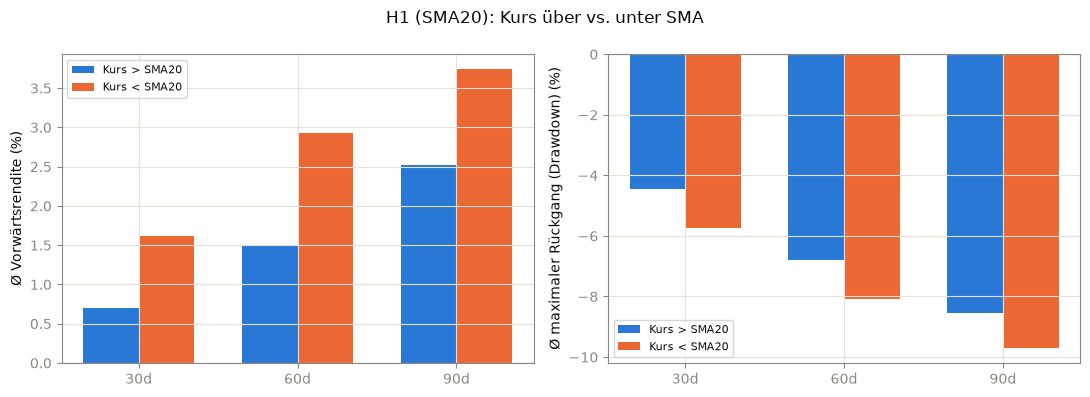

In [15]:
# Stellvertretend für das empfindlichste Fenster (SMA20) - SMA100/SMA200 folgen in den nächsten beiden Zellen
plotte_gruppenvergleich(tabelle_h1[tabelle_h1["sma_fenster"] == 20], "H1 (SMA20): Kurs über vs. unter SMA")


**Ergebnis SMA20:** Für beide Zielgrößen liegt in allen drei Horizonten
statistische Signifikanz vor, allerdings in gegenläufiger Richtung: Der
maximale Rückgang war bei einem Kurs über SMA20 durchgehend signifikant
geringer (90 Tage: −8,5 % gegenüber −9,7 %). Die Rendite verhielt sich
entgegen der intuitiven Erwartung – sie war bei einem Kurs *unter* SMA20
signifikant höher (90 Tage: 3,7 % gegenüber 2,5 %). Dieses Muster
entspricht einem Mean-Reversion-Effekt: kurzfristige Schwächephasen
erholten sich historisch überdurchschnittlich häufig.

**Praxisrelevanz für Börseninvestoren:** Ein Investor, der SMA20 als
kurzfristiges Signal heranzieht, sollte nicht davon ausgehen, dass ein
Kurs über SMA20 automatisch die höhere erwartete Rendite bietet – historisch
war eher das Gegenteil der Fall. Als kurzfristiger Risikofilter ist SMA20
hingegen brauchbar: Phasen unterhalb des SMA20 gingen mit signifikant
größeren Rückgängen einher.

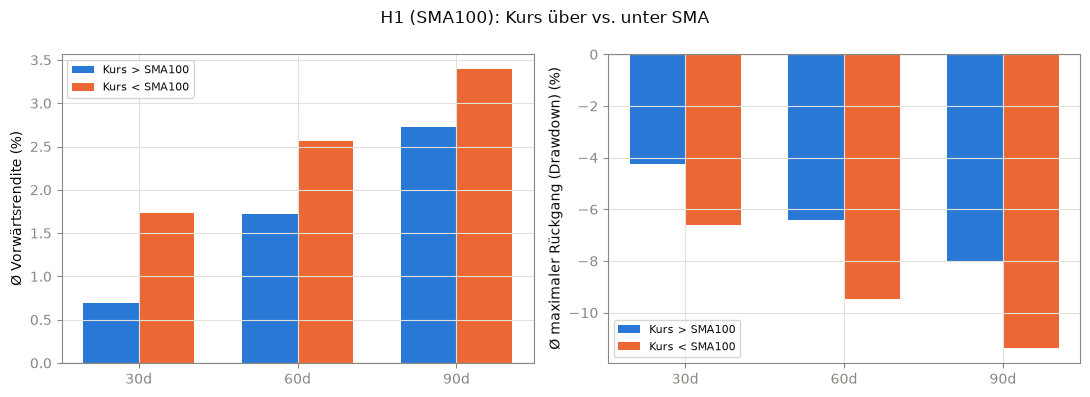

In [16]:
# Gleiche Auswertung wie oben, hier für das mittlere Fenster SMA100
plotte_gruppenvergleich(tabelle_h1[tabelle_h1["sma_fenster"] == 100], "H1 (SMA100): Kurs über vs. unter SMA")


**Ergebnis SMA100:** Der Risikounterschied bleibt über alle Horizonte
signifikant zugunsten von "Kurs über SMA100" (90 Tage: −8,0 % gegenüber
−11,4 %). Bei der Rendite zeigt sich auch bei diesem mittleren Fenster in
allen drei Horizonten noch ein signifikanter Mean-Reversion-Effekt: Der
Kurs unter SMA100 war durchgehend mit der höheren mittleren Rendite
verbunden (90 Tage: 3,4 % gegenüber 2,7 %), wenn auch mit über die
Horizonte abnehmender statistischer Absicherung.

**Praxisrelevanz für Börseninvestoren:** SMA100 zeigt damit denselben
gegenläufigen Renditeeffekt wie SMA20 – der Kurs unter dem SMA war
historisch tendenziell mit der höheren Folgerendite verbunden –, wenn auch
mit abnehmender statistischer Absicherung über längere Horizonte. Als
Risikofilter bleibt SMA100 dagegen durchgehend belastbar und stellt für
einen Investor, der einen Kompromiss zwischen Reaktionsgeschwindigkeit und
Signalstabilität sucht, weiterhin eine sinnvolle Zwischenstufe dar.

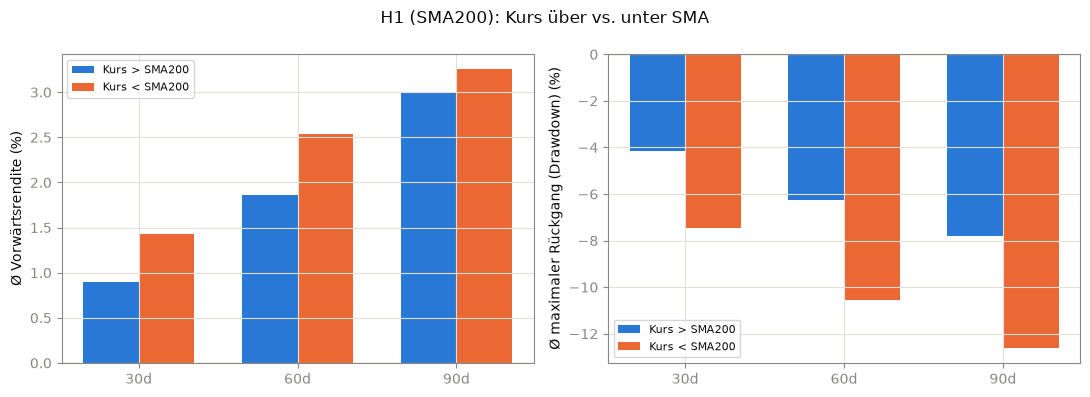

In [17]:
# Gleiche Auswertung wie oben, hier für das langfristige Fenster SMA200 -
# im Notebook als robusteste Basis identifiziert (siehe Ergebnis-Text unten)
plotte_gruppenvergleich(tabelle_h1[tabelle_h1["sma_fenster"] == 200], "H1 (SMA200): Kurs über vs. unter SMA")


**Ergebnis SMA200:** Der Risikounterschied bleibt über alle Horizonte
signifikant: Der maximale Rückgang war bei einem Kurs über SMA200
durchgehend deutlich geringer (90 Tage: −7,8 % gegenüber −12,6 %). Bei der
Rendite zeigt sich – anders als bei SMA20 – eine schwächere Signifikanz:
Bei 30 und 60 Tagen ist der Renditevorsprung eines Kurses unter dem SMA200
(Mean-Reversion) noch signifikant nachweisbar, beim 90-Tage-Horizont
gleichen sich beide Gruppen mit 3,0 % (über SMA200) gegenüber 3,3 % (unter
SMA200) an, und der Unterschied ist dort nicht mehr statistisch
abgesichert.

**Praxisrelevanz für Börseninvestoren:** SMA200 eignet sich unter den drei
geprüften Fenstern weiterhin am ehesten als robustes Risikosignal für
längerfristig orientierte Investoren. Als eigenständige Renditeprognose ist
es nicht durchgehend abgesichert – bei kürzeren Horizonten (30/60 Tage)
zeigt sich noch derselbe gegenläufige Mean-Reversion-Effekt wie bei den
kürzeren SMA-Fenstern, der sich erst beim 90-Tage-Horizont statistisch
auflöst.

In [18]:
def regime_laufzeiten(ueber: pd.Series, unter: pd.Series, label_ueber: str, label_unter: str) -> pd.DataFrame:
    # Fasst aufeinanderfolgende Tage mit gleichem Zustand zu Phasen (Blöcken)
    # zusammen und misst deren Länge - Grundlage für die Auswertung, wie
    # lange ein Regime typischerweise anhält.
    zustand = pd.Series(index=df.index, dtype="object")
    zustand[ueber] = label_ueber
    zustand[unter] = label_unter
    zustand = zustand.dropna()
    block = (zustand != zustand.shift()).cumsum()
    return zustand.groupby(block).agg(zustand="first", laenge="size").reset_index(drop=True)


ueber200, unter200 = regime_gruppen(200)
laufzeiten200 = regime_laufzeiten(ueber200, unter200, "Kurs > SMA200", "Kurs < SMA200")

print(f"Anzahl Regime-Phasen seit 2007 (SMA200): {len(laufzeiten200)}")
print(laufzeiten200.groupby("zustand")["laenge"].agg(["count", "median", "mean", "max"]))


Anzahl Regime-Phasen seit 2007 (SMA200): 145
               count  median    mean  max
zustand                                  
Kurs < SMA200     72  4.0000 15.8750  262
Kurs > SMA200     73  5.0000 49.1507  501


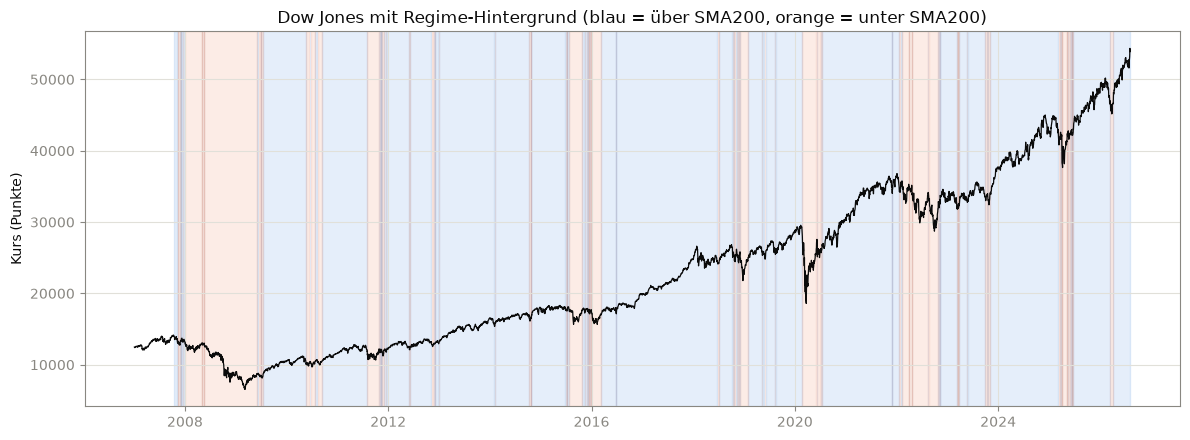

In [19]:
# Kursverlauf mit farblich hinterlegtem Regime-Hintergrund: macht die in
# regime_laufzeiten() gemessenen, teils mehrjährigen Phasen visuell sichtbar.
fig, achse = plt.subplots(figsize=(12, 4.5))
achse.fill_between(df.index, 0, 1, where=ueber200, color=COLOR_A, alpha=0.12, transform=achse.get_xaxis_transform())
achse.fill_between(df.index, 0, 1, where=unter200, color=COLOR_B, alpha=0.12, transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title("Dow Jones mit Regime-Hintergrund (blau = über SMA200, orange = unter SMA200)")
fig.tight_layout()
plt.show()


**Ergänzende Betrachtung – Regime-Laufzeiten:** Seit 2007 wechselte das
SMA200-Regime 145-mal, mit einer medianen Phasendauer von 4 (unter SMA200)
bzw. 5 (über SMA200) Handelstagen – die Mittelwerte liegen jedoch deutlich
darüber, da einzelne Phasen mehrere Jahre andauern können (Maximum: 262
bzw. 501 Handelstage). Das Fenster wechselt damit zwischen zahlreichen
kurzlebigen Episoden und einzelnen sehr lang anhaltenden Phasen, was den im
Kursverlauf-Chart sichtbaren, unterschiedlich langen Marktphasen
entspricht.

**Praxisrelevanz für Börseninvestoren:** Mit rund 7 bis 8 Regimewechseln
pro Jahr bleibt SMA200 auch für den Dow Jones ein Signal, das nicht ständig
zwischen den Zuständen wechselt ("Signalflackern"), was bei einer
regelbasierten Anwendung Transaktionskosten und Fehlsignale begrenzt hält –
auch wenn die im Median kurzen Phasendauern zeigen, dass ein Teil der
Wechsel nur kurzlebige Übergänge sind.

### 4.2 H2 – SMA-Richtung (steigend oder fallend)

**Hypothese:** Nicht nur die Position des Kurses relativ zum SMA, sondern
auch die Richtung des SMA selbst (steigend oder fallend gegenüber dem
Vortag) trägt Information über die Folgeperiode. Geprüft wird dies analog
zu H1 für SMA20, SMA100 und SMA200.


In [20]:
def regime_gruppen_richtung(sma_fenster: int) -> tuple[pd.Series, pd.Series]:
    # Richtung des SMA (Tagesveränderung) statt seines Niveaus - unabhängig
    # von der Position des Kurses relativ zum SMA (H1).
    sma_diff = df[f"SMA{sma_fenster}_d"].diff()
    valide = sma_diff.notna()
    steigend = (sma_diff > 0) & valide
    fallend = (sma_diff <= 0) & valide
    return steigend, fallend


ergebnisse_h2 = []
for w in SMA_WINDOWS_DAILY:
    steigend, fallend = regime_gruppen_richtung(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[steigend, f"{ziel}_{h}d"], df.loc[fallend, f"{ziel}_{h}d"],
                label_a=f"SMA{w} steigend", label_b=f"SMA{w} fallend",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgroesse": ziel})
                ergebnisse_h2.append(res)

tabelle_h2 = ergebnisse_zu_tabelle(ergebnisse_h2)
alle_ergebnisse["H2_SMA_Richtung"] = tabelle_h2
tabelle_h2[spalten_anzeige]


,sma_fenster,horizont_tage,zielgroesse,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,SMA20 steigend,0.0071,SMA20 fallend,0.0162,0.0000,0.0000,True
1,20,30,fwd_mdd,SMA20 steigend,-0.0441,SMA20 fallend,-0.0582,0.0000,0.0000,True
2,20,60,fwd_return,SMA20 steigend,0.0151,SMA20 fallend,0.0295,0.0000,0.0000,True
3,20,60,fwd_mdd,SMA20 steigend,-0.0680,SMA20 fallend,-0.0812,0.0000,0.0000,True
4,20,90,fwd_return,SMA20 steigend,0.0260,SMA20 fallend,0.0364,0.0002,0.0000,True
5,20,90,fwd_mdd,SMA20 steigend,-0.0850,SMA20 fallend,-0.0981,0.0000,0.0000,True
6,100,30,fwd_return,SMA100 steigend,0.0092,SMA100 fallend,0.0120,0.1890,0.0000,False
7,100,30,fwd_mdd,SMA100 steigend,-0.0423,SMA100 fallend,-0.0677,0.0000,0.0000,True
8,100,60,fwd_return,SMA100 steigend,0.0188,SMA100 fallend,0.0220,0.2634,0.0000,False
9,100,60,fwd_mdd,SMA100 steigend,-0.0639,SMA100 fallend,-0.0968,0.0000,0.0000,True


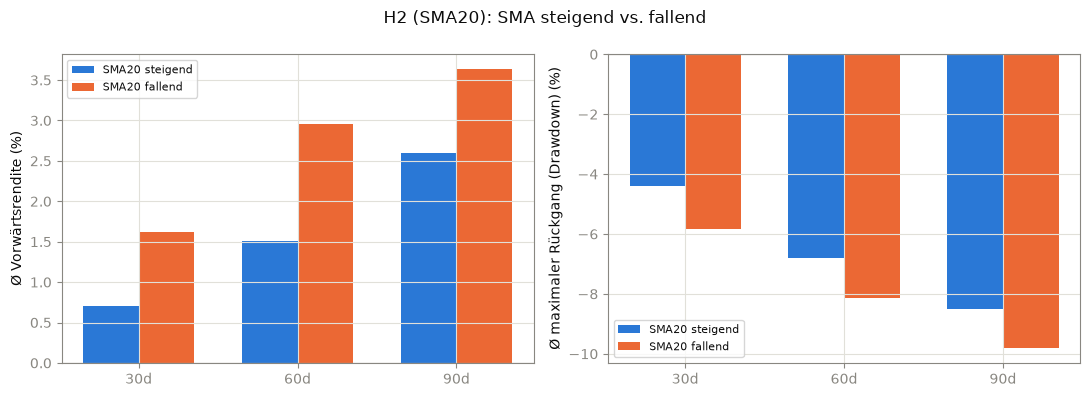

In [21]:
# Stellvertretend für SMA20 - SMA100/SMA200 folgen in den nächsten beiden Zellen
plotte_gruppenvergleich(tabelle_h2[tabelle_h2["sma_fenster"] == 20], "H2 (SMA20): SMA steigend vs. fallend")


**Ergebnis SMA20:** Wie bei H1 zeigt sich ein durchgehend signifikanter,
gegenläufiger Zusammenhang: geringeres Risiko bei steigendem SMA20 (90
Tage: −8,5 % gegenüber −9,8 %), gleichzeitig signifikant höhere Rendite bei
fallendem SMA20 in allen drei Horizonten (90 Tage: 3,6 % gegenüber 2,6 %).

**Praxisrelevanz für Börseninvestoren:** Die Richtung des kurzfristigen
SMA20 bestätigt das bei H1 beobachtete Muster und liefert keine
eigenständige zusätzliche Information gegenüber der reinen Kursposition
zum SMA20.

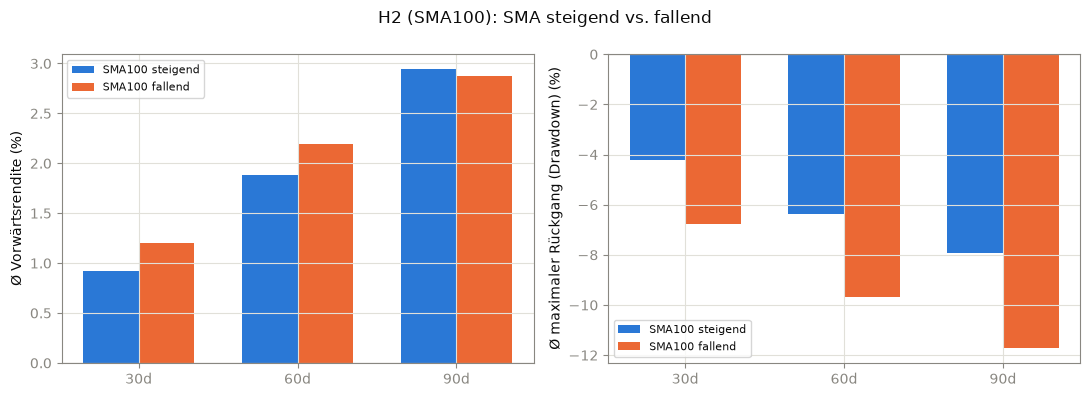

In [22]:
# Gleiche Auswertung wie oben, hier für SMA100
plotte_gruppenvergleich(tabelle_h2[tabelle_h2["sma_fenster"] == 100], "H2 (SMA100): SMA steigend vs. fallend")


**Ergebnis SMA100:** Der Risikounterschied bleibt über alle Horizonte
signifikant zugunsten von "SMA100 steigend" (90 Tage: −7,9 % gegenüber
−11,7 %). Bei der Rendite zeigt sich ein uneinheitliches, in keinem
Horizont statistisch signifikantes Bild: Bei 30 und 60 Tagen liegt die
mittlere Rendite bei fallendem SMA100 geringfügig höher (30 Tage: 1,2 %
gegenüber 0,9 %), beim 90-Tage-Horizont kehrt sich dieses Verhältnis knapp
um (steigend 3,0 % gegenüber fallend 2,9 %) – in allen drei Fällen bewegen
sich die Unterschiede im Bereich der Zufallsstreuung.

**Praxisrelevanz für Börseninvestoren:** SMA100-Richtung liefert kein
statistisch abgesichertes Renditesignal und wechselt in der Tendenz sogar
je nach Horizont die Richtung; als Risikofilter ist SMA100 dagegen
durchgehend belastbar.

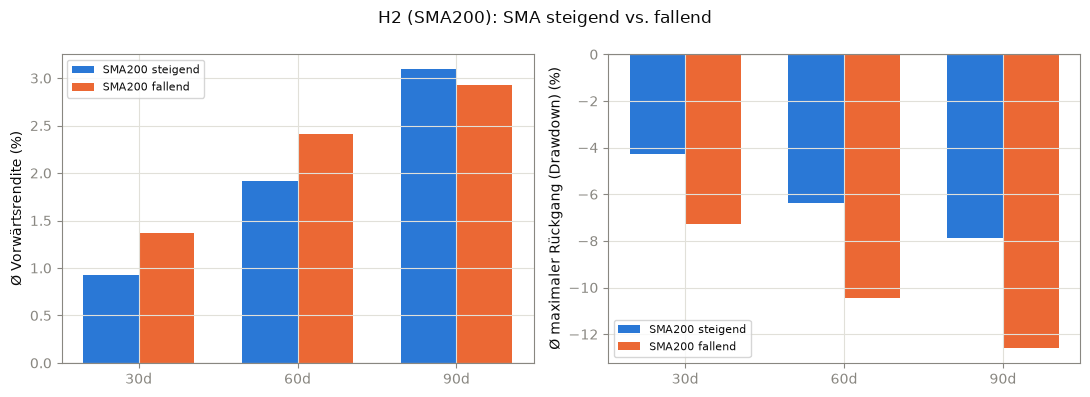

In [23]:
# Gleiche Auswertung wie oben, hier für SMA200
plotte_gruppenvergleich(tabelle_h2[tabelle_h2["sma_fenster"] == 200], "H2 (SMA200): SMA steigend vs. fallend")


**Ergebnis SMA200:** Der Risikounterschied bleibt signifikant (90 Tage:
−7,9 % gegenüber −12,6 %). Die Rendite zeigt kein konsistentes Bild (30
Tage: fallend mit 1,4 % gegenüber 0,9 % höher; 60 Tage: fallend mit 2,4 %
gegenüber 1,9 % weiterhin höher; 90 Tage: steigend mit 3,1 % gegenüber
2,9 % knapp höher) – in keinem Fall statistisch signifikant.

**Praxisrelevanz für Börseninvestoren:** Die Richtung des SMA200 eignet
sich – wie die Position des Kurses zu SMA200 bei H1 – primär als
Risikoindikator, nicht als Renditesignal.

In [24]:
# Regime-Laufzeiten der SMA200-Richtung (analog zu Zelle "regime_laufzeiten" bei
# H1) - dient als zweiter Beleg für die geringe Wechselhäufigkeit
# langfristiger SMA-Zustände.
steigend200, fallend200 = regime_gruppen_richtung(200)
laufzeiten_h2 = regime_laufzeiten(steigend200, fallend200, "SMA200 steigend", "SMA200 fallend")

print(f"Anzahl Regime-Phasen seit 2007 (SMA200-Richtung): {len(laufzeiten_h2)}")
print(laufzeiten_h2.groupby("zustand")["laenge"].agg(["count", "median", "mean", "max"]))


Anzahl Regime-Phasen seit 2007 (SMA200-Richtung): 157
                 count  median    mean  max
zustand                                    
SMA200 fallend      78  2.0000 13.8205  384
SMA200 steigend     79  3.0000 46.2278  610


**Ergänzende Betrachtung – Regime-Laufzeiten:** Die Richtung des SMA200
wechselte seit 2007 157-mal – geringfügig häufiger als die Kursposition zu
SMA200 bei H1 (145 Wechsel). Steigende Phasen dauerten im Mittel deutlich
länger an (bis zu 610 Handelstage) als fallende Phasen (bis zu 384
Handelstage), bei einer medianen Dauer von 3 (steigend) bzw. 2 (fallend)
Handelstagen.

**Praxisrelevanz für Börseninvestoren:** Trotz der etwas höheren
Wechselhäufigkeit bleibt die SMA200-Richtung durch die vereinzelten sehr
langen Phasen im Mittel ein träges, stabiles Signal – geeignet als
langfristiger Kontextindikator, weniger geeignet für kurzfristige
Entscheidungen angesichts der ebenfalls häufigen kurzen Wechsel.

### 4.3 H3 – Cross-Over (Golden Cross / Death Cross)

**Hypothese:** Das Kreuzen eines kurzfristigen SMA über einen langfristigen
SMA von unten nach oben (**Golden Cross**) bzw. von oben nach unten
(**Death Cross**) gilt als klassisches technisches Signal. Geprüft werden
alle neun möglichen SMA-Paare über Tages-, Wochen- und Monatsbasis.


In [25]:
def finde_crossover(sma_kurz: pd.Series, sma_lang: pd.Series) -> tuple[pd.Series, pd.Series]:
    # Golden Cross: kurzer SMA kreuzt den langen SMA von unten nach oben.
    # Death Cross: umgekehrte Richtung. shift(1) vergleicht mit dem Vortag,
    # damit nur der tatsächliche Kreuzungstag markiert wird, nicht jeder Tag
    # der jeweiligen Lage.
    golden = (sma_kurz.shift(1) <= sma_lang.shift(1)) & (sma_kurz > sma_lang)
    death = (sma_kurz.shift(1) >= sma_lang.shift(1)) & (sma_kurz < sma_lang)
    return golden, death


# Alle neun sinnvollen SMA-Paare je Zeitbasis (kurzes vor langem Fenster)
crossover_paare = [
    (20, 100, "d"), (20, 200, "d"), (100, 200, "d"),
    (20, 100, "w"), (20, 200, "w"), (100, 200, "w"),
    (20, 50, "m"), (20, 75, "m"), (50, 75, "m"),
]

ergebnisse_h3 = []
for kurz, lang, basis in crossover_paare:
    golden, death = finde_crossover(df[f"SMA{kurz}_{basis}"], df[f"SMA{lang}_{basis}"])
    n_golden, n_death = int(golden.sum()), int(death.sum())

    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[golden, f"{ziel}_{h}d"], df.loc[death, f"{ziel}_{h}d"],
                label_a=f"Golden Cross SMA{kurz}/{lang} ({basis})", label_b=f"Death Cross SMA{kurz}/{lang} ({basis})",
            )
            if res:
                res.update({"zeitbasis": basis, "sma_kurz": kurz, "sma_lang": lang,
                            "n_golden_events": n_golden, "n_death_events": n_death,
                            "horizont_tage": h, "zielgroesse": ziel})
                ergebnisse_h3.append(res)

tabelle_h3 = ergebnisse_zu_tabelle(ergebnisse_h3)
alle_ergebnisse["H3_CrossOver"] = tabelle_h3
cols_h3 = ["zeitbasis", "sma_kurz", "sma_lang", "n_golden_events", "n_death_events", "horizont_tage",
           "zielgroesse", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]
tabelle_h3[cols_h3]


,zeitbasis,sma_kurz,sma_lang,n_golden_events,n_death_events,horizont_tage,zielgroesse,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,d,20,100,34,34,30,fwd_return,0.0067,0.0249,0.0955,0.0805,False
1,d,20,100,34,34,30,fwd_mdd,-0.0443,-0.0486,0.6756,0.9365,False
2,d,20,100,34,34,60,fwd_return,0.0175,0.0375,0.1814,0.0763,False
3,d,20,100,34,34,60,fwd_mdd,-0.0652,-0.0753,0.4035,0.5316,False
4,d,20,100,34,34,90,fwd_return,0.0277,0.0485,0.2929,0.0700,False
5,d,20,100,34,34,90,fwd_mdd,-0.0788,-0.0912,0.3717,0.7971,False
6,d,20,200,14,14,30,fwd_return,0.0208,0.0049,0.3772,0.3232,False
7,d,20,200,14,14,30,fwd_mdd,-0.0390,-0.0805,0.0146,0.0158,True
8,d,20,200,14,14,60,fwd_return,0.0377,0.0455,0.7544,0.9451,False
9,d,20,200,14,14,60,fwd_mdd,-0.0537,-0.0900,0.0312,0.0456,True


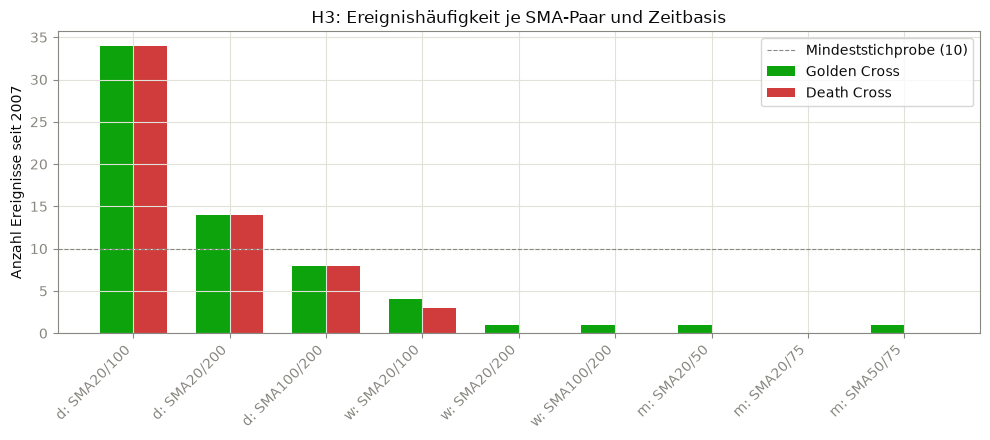

In [26]:
# Ereignishäufigkeit je Paar/Zeitbasis - zeigt, welche Paare überhaupt genug
# Beobachtungen für einen belastbaren Test liefern (vergleiche_gruppen()
# verlangt implizit mind. 10 Ereignisse je Gruppe).
uebersicht_ereignisse = []
for kurz, lang, basis in crossover_paare:
    golden, death = finde_crossover(df[f"SMA{kurz}_{basis}"], df[f"SMA{lang}_{basis}"])
    uebersicht_ereignisse.append({"zeitbasis": basis, "paar": f"SMA{kurz}/{lang}",
                                   "n_golden": int(golden.sum()), "n_death": int(death.sum())})
tabelle_ereignisse_h3 = pd.DataFrame(uebersicht_ereignisse)

fig, achse = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(tabelle_ereignisse_h3))
breite = 0.35
etiketten = [f"{r.zeitbasis}: {r.paar}" for r in tabelle_ereignisse_h3.itertuples()]
achse.bar(x - breite / 2, tabelle_ereignisse_h3["n_golden"], breite, label="Golden Cross", color=COLOR_GOOD)
achse.bar(x + breite / 2, tabelle_ereignisse_h3["n_death"], breite, label="Death Cross", color=COLOR_BAD)
achse.axhline(10, color=COLOR_MUTED, linewidth=0.8, linestyle="--", label="Mindeststichprobe (10)")
achse.set_xticks(x)
achse.set_xticklabels(etiketten, rotation=45, ha="right")
achse.set_ylabel("Anzahl Ereignisse seit 2007")
achse.legend()
plt.title("H3: Ereignishäufigkeit je SMA-Paar und Zeitbasis")
plt.tight_layout()
plt.show()


**Ergebnis – Ereignishäufigkeit:** Von neun geprüften Paaren erreichen nur
zwei die Mindeststichprobe von 10 Ereignissen je Richtung – beide auf
Tagesbasis (SMA20/100 mit 34/34, SMA20/200 mit 14/14 Ereignissen). Das
dritte Tagesbasis-Paar (SMA100/200) bleibt mit 8/8 Ereignissen knapp
darunter; alle sechs Wochen- und Monatsbasis-Paare liegen mit 0 bis 4
Ereignissen noch deutlich niedriger. Über den gesamten Analysezeitraum von
rund 19,6 Jahren sind damit sieben der neun Paare für eine statistische
Aussage nicht geeignet.

**Praxisrelevanz für Börseninvestoren:** Cross-Over-Signale auf Wochen-
oder Monatsbasis, wie sie in der Praxis gelegentlich als "robustere"
Variante des klassischen Signals beworben werden, treten in diesem
Datensatz zu selten auf, um überhaupt eine belastbare Handelsregel zu
begründen.

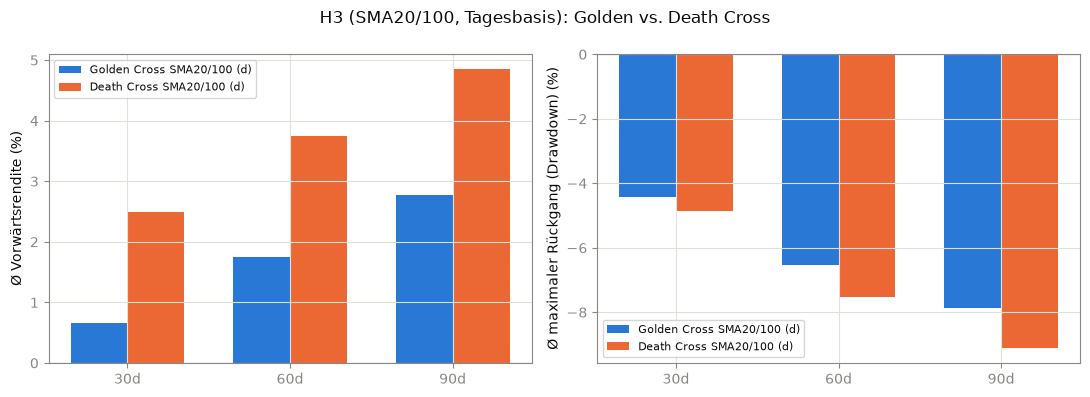

In [27]:
# Häufigstes testbares Paar (Tagesbasis)
teil_20_100 = tabelle_h3[(tabelle_h3["sma_kurz"] == 20) & (tabelle_h3["sma_lang"] == 100) & (tabelle_h3["zeitbasis"] == "d")]
plotte_gruppenvergleich(teil_20_100, "H3 (SMA20/100, Tagesbasis): Golden vs. Death Cross")


**Ergebnis SMA20/100 (Tagesbasis, 34/34 Ereignisse):** Trotz der mit 34
Ereignissen je Richtung vergleichsweise umfangreichen Stichprobe ist in
keinem der sechs geprüften Kombinationen (drei Horizonte × zwei
Zielgrößen) ein statistisch signifikanter Unterschied zwischen Golden und
Death Cross nachweisbar.

**Praxisrelevanz für Börseninvestoren:** Für dieses – in der Praxis häufig
verwendete – SMA-Paar liefert das klassische Cross-Over-Signal in den
vorliegenden Daten keinen statistisch abgesicherten Handlungshinweis;
weder für die erwartete Rendite noch für das Risiko.

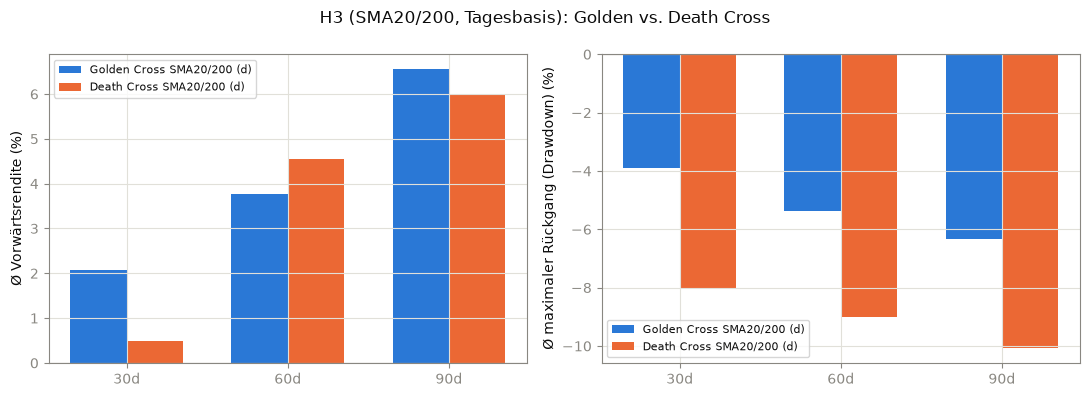

In [28]:
# Selteneres der beiden testbaren Paare (Tagesbasis)
teil_20_200 = tabelle_h3[(tabelle_h3["sma_kurz"] == 20) & (tabelle_h3["sma_lang"] == 200) & (tabelle_h3["zeitbasis"] == "d")]
plotte_gruppenvergleich(teil_20_200, "H3 (SMA20/200, Tagesbasis): Golden vs. Death Cross")


**Ergebnis SMA20/200 (Tagesbasis, 14/14 Ereignisse):** Bei diesem
selteneren Paar ist der Unterschied beim maximalen Rückgang in den ersten
beiden Horizonten statistisch signifikant (Death Cross mit deutlich
größeren Rückgängen, z. B. 60 Tage: −9,0 % gegenüber −5,4 %); beim
90-Tage-Horizont verfehlt der Unterschied trotz ähnlicher Größenordnung
(−10,1 % gegenüber −6,3 %) knapp die Signifikanzschwelle
(Mann-Whitney-U-Test: p = 0,058). Der Renditeunterschied bleibt in keinem
Horizont signifikant.

**Praxisrelevanz für Börseninvestoren:** Dieses seltenere Cross-Over-Signal
liefert – anders als das häufigere SMA20/100-Paar – zumindest in den
kürzeren Horizonten ein statistisch abgesichertes Risikosignal, tritt
jedoch mit nur 14 Ereignissen seit 2007 zu selten auf, um als alleinige
Handlungsgrundlage zu dienen.

### 4.4 H4 – Divergenz zwischen kurz- und längerfristigem Trend

**Hypothese:** Ein kurzfristiger Rücksetzer innerhalb eines intakten
längerfristigen Aufwärtstrends könnte eine überdurchschnittlich günstige
Ausgangslage markieren. Geprüft werden zwei Divergenzmuster (jeweils mit
SMA20, dem empfindlichsten Fenster):

- **D1 (Tages-/Wochenbasis):** Der Tages-SMA20 fällt mindestens fünf
  Handelstage in Folge, während der Wochen-SMA20 gleichzeitig steigt, und
  der Tages-SMA20 beginnt anschließend wieder zu steigen.
- **D2 (Wochen-/Monatsbasis):** dieselbe Logik eine Zeitebene höher: der
  Wochen-SMA20 fällt mindestens fünf Wochen in Folge, während der
  Monats-SMA20 gleichzeitig steigt.


In [29]:
def konsekutive_rueckgangs_laenge(s: pd.Series) -> pd.Series:
    # Zählt für jeden Tag, wie viele Tage in Folge die Reihe bis dahin bereits
    # gefallen ist (0, falls der Vortag nicht gefallen ist) - Basis für das
    # "mindestens 5 Tage in Folge fallend"-Kriterium von D1/D2.
    faellt = s.diff() < 0
    gruppe = (~faellt).cumsum()
    return faellt.astype(int).groupby(gruppe).cumsum()


sma_d = df["SMA20_d"]
sma_w = df["SMA20_w"]

rueckgangs_laenge_d = konsekutive_rueckgangs_laenge(sma_d).shift(1)
tages_sma_dreht_wieder = sma_d.diff() > 0
wochen_sma_steigt = sma_w.diff() > 0

# D1-Ereignis: Tages-SMA20 dreht nach mind. 5 Tagen Rückgang wieder nach
# oben, während der übergeordnete Wochen-SMA20 währenddessen weiter steigt.
event_d1 = tages_sma_dreht_wieder & (rueckgangs_laenge_d >= 5) & wochen_sma_steigt
print(f"D1-Ereignisse identifiziert: {int(event_d1.sum())}")

ergebnisse_h4 = []
for h in HORIZONS:
    for ziel in ["fwd_return", "fwd_mdd"]:
        res = vergleiche_gruppen(
            df.loc[event_d1, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
            label_a="D1-Signal (Tage/Woche)", label_b="Basisrate (alle Tage)",
        )
        if res:
            res.update({"muster": "D1_tage_woche", "horizont_tage": h, "zielgroesse": ziel, "n_events": int(event_d1.sum())})
            ergebnisse_h4.append(res)


D1-Ereignisse identifiziert: 15


In [30]:
# D2 wird auf nativer Wochen-/Monatsbasis berechnet (statt wie D1 über die
# auf Tagesbasis gemappten Spalten), damit "5 Wochen in Folge fallend" exakt
# der fachlichen Definition entspricht und nicht durch das Mapping auf
# Handelstage verzerrt wird.
wochenschluss_nativ = df["Close"].resample("W-FRI").last().dropna()
wochen_sma_nativ = wochenschluss_nativ.rolling(20, min_periods=20).mean()

monatsschluss_nativ = df["Close"].resample("ME").last().dropna()
monats_sma_nativ = monatsschluss_nativ.rolling(20, min_periods=20).mean()

monat_auf_woche = pd.merge_asof(
    wochen_sma_nativ.reset_index()[["Date"]],
    monats_sma_nativ.rename("monat_sma").reset_index(),
    on="Date", direction="backward",
)["monat_sma"]
monat_auf_woche.index = wochen_sma_nativ.index

rueckgangs_laenge_w = konsekutive_rueckgangs_laenge(wochen_sma_nativ).shift(1)
wochen_sma_dreht_wieder = wochen_sma_nativ.diff() > 0
monat_sma_steigt = monat_auf_woche.diff() > 0

# D2-Ereignis: gleiche Logik wie D1, eine Zeitebene höher (Woche/Monat statt Tag/Woche)
event_d2_woechentlich = wochen_sma_dreht_wieder & (rueckgangs_laenge_w >= 5) & monat_sma_steigt
print(f"D2-Ereignisse identifiziert (Wochenbasis): {int(event_d2_woechentlich.sum())}")

# Wochenbasierte Ereignistermine auf den jeweils folgenden Handelstag
# gemappt, damit sie mit den tagesbasierten fwd_-Zielgrößen verglichen werden können.
event_d2_termine = event_d2_woechentlich[event_d2_woechentlich].index
if len(event_d2_termine) > 0:
    d2_auf_tage = pd.merge_asof(
        pd.DataFrame({"Date": event_d2_termine}).sort_values("Date"),
        df.reset_index()[["Date"]], on="Date", direction="forward",
    )["Date"]
    event_d2_taeglich = df.index.isin(d2_auf_tage)
else:
    event_d2_taeglich = pd.Series(False, index=df.index)

for h in HORIZONS:
    for ziel in ["fwd_return", "fwd_mdd"]:
        res = vergleiche_gruppen(
            df.loc[event_d2_taeglich, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
            label_a="D2-Signal (Woche/Monat)", label_b="Basisrate (alle Tage)",
        )
        if res:
            res.update({"muster": "D2_woche_monat", "horizont_tage": h, "zielgroesse": ziel, "n_events": int(event_d2_taeglich.sum())})
            ergebnisse_h4.append(res)

tabelle_h4 = ergebnisse_zu_tabelle(ergebnisse_h4)
alle_ergebnisse["H4_Divergenz"] = tabelle_h4
cols_h4 = ["muster", "n_events", "horizont_tage", "zielgroesse", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]
tabelle_h4[cols_h4]


D2-Ereignisse identifiziert (Wochenbasis): 2


,muster,n_events,horizont_tage,zielgroesse,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,D1_tage_woche,15,30,fwd_return,0.0221,0.0103,0.1180,0.2965,False
1,D1_tage_woche,15,30,fwd_mdd,-0.0337,-0.0491,0.0127,0.1461,False
2,D1_tage_woche,15,60,fwd_return,0.0214,0.0203,0.9400,0.9159,False
3,D1_tage_woche,15,60,fwd_mdd,-0.0642,-0.0727,0.3871,0.8903,False
4,D1_tage_woche,15,90,fwd_return,0.0156,0.0300,0.2994,0.1870,False
5,D1_tage_woche,15,90,fwd_mdd,-0.0840,-0.0896,0.5783,0.5916,False


**Ergebnis D2:** Mit lediglich zwei identifizierten Ereignissen seit 2007
liegt D2 deutlich unterhalb der Mindeststichprobe von 10 Beobachtungen und
wird aus diesem Grund nicht statistisch getestet und nicht grafisch
ausgewertet – eine Auswertung auf Basis von zwei Einzelfällen wäre nicht
belastbar.

**Praxisrelevanz für Börseninvestoren:** Je höher die betrachtete
Zeitebene, desto seltener tritt das Divergenzmuster auf. Für ein
Divergenzsignal auf Wochen-/Monatsbasis liegt in fast zwei Jahrzehnten
schlicht nicht genügend Historie vor, um es als Entscheidungsgrundlage
heranzuziehen.


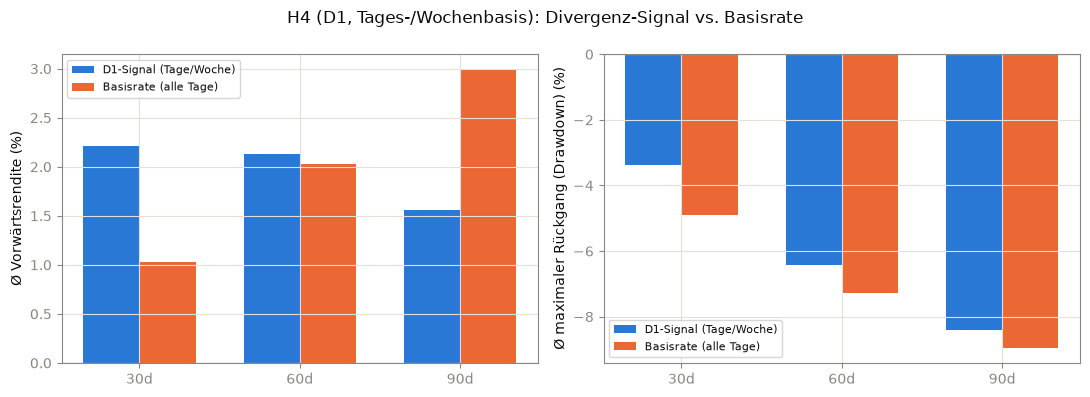

In [31]:
# D2 wird hier bewusst nicht abgebildet (nur 2 Ereignisse, siehe Ergebnistext)
plotte_gruppenvergleich(tabelle_h4[tabelle_h4["muster"] == "D1_tage_woche"], "H4 (D1, Tages-/Wochenbasis): Divergenz-Signal vs. Basisrate")


**Ergebnis D1 (15 Ereignisse):** In keiner der sechs geprüften
Kombinationen (drei Horizonte × zwei Zielgrößen) ist ein statistisch
signifikanter Unterschied zwischen dem D1-Signal und der Basisrate (allen
Handelstagen) nachweisbar. Am nächsten an der Signifikanzschwelle liegt der
maximale Rückgang im 30-Tage-Horizont (−3,4 % gegenüber −4,9 %
Basisrate): Der Welch-t-Test weist hier mit p = 0,013 auf einen
Unterschied hin, der ergänzend herangezogene Mann-Whitney-U-Test mit
p = 0,146 jedoch nicht – die geforderte gemeinsame Signifikanz beider
Tests wird damit verfehlt. Der Renditeunterschied bleibt in keinem
Horizont signifikant.

**Praxisrelevanz für Börseninvestoren:** Mit 15 Ereignissen seit 2007 ist
D1 statistisch fragil; in den vorliegenden Daten liefert das Muster keinen
statistisch abgesicherten Hinweis auf ein günstigeres Risiko- oder
Renditeprofil und sollte allenfalls als deskriptiver, nicht als
belastbarer Indikator verstanden werden.

### 4.5 H5 – Abstand vom bisherigen Hoch (Drawdown-Status)

**Hypothese:** Der prozentuale Abstand des aktuellen Kurses zu seinem
bisherigen Höchststand (Allzeithoch) liefert Information über die
Folgeperiode – unabhängig von einer SMA-Fensterwahl. Diese Kennzahl
entspricht der in der Praxis gebräuchlichen Korrektur- (ab −10 %) und
Bärenmarkt-Definition (ab −20 %).


In [32]:
# Allzeithoch als laufendes Maximum des Schlusskurses; Abstand_vom_Hoch ist
# damit unabhängig von jeder SMA-Fensterwahl und entspricht der in der Praxis
# gebräuchlichen Korrektur-/Bärenmarkt-Definition.
df["Allzeithoch"] = df["Close"].cummax()
df["Abstand_vom_Hoch"] = df["Close"] / df["Allzeithoch"] - 1


def drawdown_bucket(x: float) -> str:
    # Vier Stufen entlang gängiger Marktdefinitionen: Korrektur ab -10 %, Bärenmarkt ab -20 %
    if x >= -0.05:
        return "Nahe am Hoch (0 bis -5%)"
    elif x >= -0.10:
        return "Leichte Korrektur (-5 bis -10%)"
    elif x >= -0.20:
        return "Korrektur (-10 bis -20%)"
    else:
        return "Bärenmarkt (< -20%)"


df["Drawdown_Bucket"] = df["Abstand_vom_Hoch"].apply(drawdown_bucket)
bucket_reihenfolge = ["Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)",
                       "Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]
print("Verteilung der Handelstage auf die vier Drawdown-Stufen:")
print(df["Drawdown_Bucket"].value_counts().reindex(bucket_reihenfolge))


Verteilung der Handelstage auf die vier Drawdown-Stufen:
Drawdown_Bucket
Nahe am Hoch (0 bis -5%)           2601
Leichte Korrektur (-5 bis -10%)     925
Korrektur (-10 bis -20%)            764
Bärenmarkt (< -20%)                 640
Name: count, dtype: int64


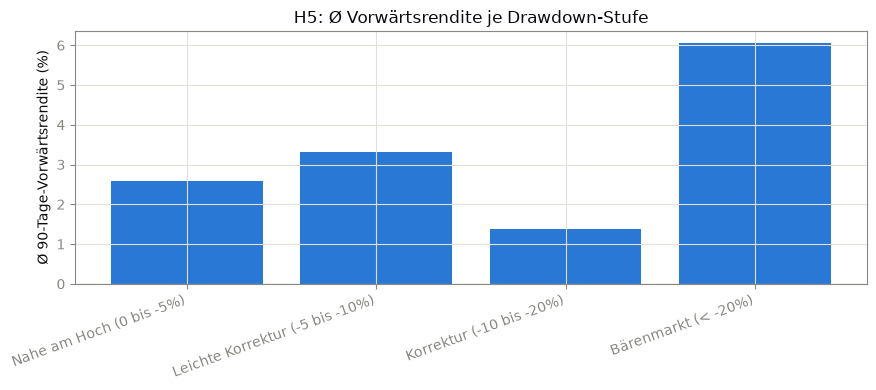

In [33]:
# Mittlere 90-Tage-Vorwärtsrendite je Drawdown-Stufe
uebersicht = df.groupby("Drawdown_Bucket")[["fwd_return_90d", "fwd_mdd_90d"]].mean().reindex(bucket_reihenfolge)
fig, achse = plt.subplots(figsize=(9, 4))
achse.bar(uebersicht.index, uebersicht["fwd_return_90d"] * 100, color=COLOR_A)
achse.set_ylabel("Ø 90-Tage-Vorwärtsrendite (%)")
achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
plt.xticks(rotation=20, ha="right")
plt.title("H5: Ø Vorwärtsrendite je Drawdown-Stufe")
plt.tight_layout()
plt.show()


**Ergebnis – Verteilung und Rendite je Stufe:** Rund 52,8 % der
Handelstage seit 2007 lagen innerhalb von 5 % des bisherigen Hochs,
während rund 13,0 % der Handelstage einem Bärenmarkt (Rückgang über
20 %) zuzuordnen sind. Die mittlere 90-Tage-Vorwärtsrendite verläuft dabei
nicht durchgehend monoton mit der Tiefe der Korrektur: Sie liegt bei
"Nahe am Hoch" bei 2,6 %, steigt bei "Leichte Korrektur" leicht auf
3,3 %, fällt bei "Korrektur" auf 1,4 % zurück und erreicht in der
tiefsten Stufe "Bärenmarkt" mit 6,0 % ihren höchsten Wert.

**Praxisrelevanz für Börseninvestoren:** Bereits die reine
Häufigkeitsverteilung ist informativ: Tiefere Korrekturphasen sind kein
Randphänomen, sondern machen mit rund 13 % Bärenmarkt- und weiteren gut
15 % Korrekturtagen einen erheblichen Teil der Handelstage aus – eine
relevante Information für die Erwartungsbildung zur Häufigkeit größerer
Rückgänge. Der nicht durchgängig monotone Renditeverlauf zeigt zudem, dass
eine pauschale Regel "je tiefer die Korrektur, desto höher die
Folgerendite" zu einfach gedacht wäre.

In [34]:
# Vergleich der beiden äußeren Drawdown-Stufen (nahe am Hoch vs. spürbare
# Korrektur) - die beiden mittleren Übergangsstufen werden hier ausgespart,
# um einen möglichst trennscharfen Test zu erhalten.
nahe_am_hoch = df["Abstand_vom_Hoch"] >= -0.05
spuerbare_korrektur = df["Abstand_vom_Hoch"] < -0.10

ergebnisse_h5 = []
for h in HORIZONS:
    for ziel in ["fwd_return", "fwd_mdd"]:
        res = vergleiche_gruppen(
            df.loc[nahe_am_hoch, f"{ziel}_{h}d"], df.loc[spuerbare_korrektur, f"{ziel}_{h}d"],
            label_a="Nahe am Hoch (bis -5%)", label_b="Spürbare Korrektur (>= -10%)",
        )
        if res:
            res.update({"horizont_tage": h, "zielgroesse": ziel})
            ergebnisse_h5.append(res)

tabelle_h5 = ergebnisse_zu_tabelle(ergebnisse_h5)
alle_ergebnisse["H5_Drawdown_vom_Hoch"] = tabelle_h5
tabelle_h5[spalten_anzeige_einfach]


,horizont_tage,zielgroesse,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,30,fwd_return,Nahe am Hoch (bis -5%),0.0070,Spürbare Korrektur (>= -10%),0.0187,0.0000,0.0000,True
1,30,fwd_mdd,Nahe am Hoch (bis -5%),-0.0405,Spürbare Korrektur (>= -10%),-0.0640,0.0000,0.0000,True
2,60,fwd_return,Nahe am Hoch (bis -5%),0.0160,Spürbare Korrektur (>= -10%),0.0294,0.0000,0.0000,True
3,60,fwd_mdd,Nahe am Hoch (bis -5%),-0.0622,Spürbare Korrektur (>= -10%),-0.0925,0.0000,0.0000,True
4,90,fwd_return,Nahe am Hoch (bis -5%),0.0259,Spürbare Korrektur (>= -10%),0.0351,0.0082,0.0000,True
5,90,fwd_mdd,Nahe am Hoch (bis -5%),-0.0784,Spürbare Korrektur (>= -10%),-0.1133,0.0000,0.0000,True


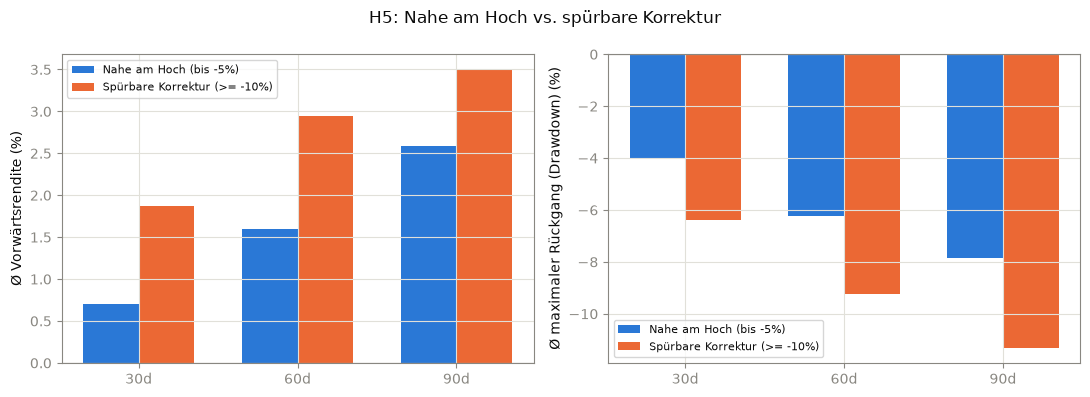

In [35]:
plotte_gruppenvergleich(tabelle_h5, "H5: Nahe am Hoch vs. spürbare Korrektur")


**Ergebnis – Signifikanztest:** Der maximale Rückgang ist in allen drei
Horizonten signifikant größer, wenn sich der Markt bereits in einer
spürbaren Korrektur (≥ 10 % unter dem Hoch) befindet, verglichen mit einer
Phase nahe am Hoch (90 Tage: −11,3 % gegenüber −7,8 %) – Korrekturen
setzen sich demnach tendenziell fort. Bei der Rendite zeigt sich das
entgegengesetzte Muster, und zwar durchgehend in allen drei Horizonten
statistisch signifikant: Die Rendite aus einer spürbaren Korrektur heraus
lag jeweils höher (90 Tage: 3,5 % gegenüber 2,6 %).

**Praxisrelevanz für Börseninvestoren:** Der Drawdown-Status eignet sich
als objektive, leicht kommunizierbare Risikokennzahl ohne
Parameterentscheidung. Für die Renditeerwartung zeigt sich hier ein
durchgehend signifikanter Mean-Reversion-Effekt: Ein tieferer Rückgang
bedeutete historisch nicht eine schlechtere, sondern eine statistisch
nachweisbar höhere erwartete Folgerendite – ein Befund, der bei der
Kommunikation an Investoren mit Vorsicht, aber auch mit Zuversicht in die
langfristige Erholungsfähigkeit des Index vermittelt werden kann.

### 4.6 H6 – Momentum (RSI)

**Hypothese:** Der Relative Strength Index (RSI) misst auf einer Skala von
0 bis 100 das Verhältnis von Aufwärts- zu Abwärtsbewegungen der letzten 14
Handelstage. Werte über 70 gelten klassisch als "überkauft", Werte unter
30 als "überverkauft" – mit der Erwartung einer nachfolgenden
Gegenbewegung.


In [36]:
def berechne_rsi(close: pd.Series, fenster: int = 14) -> pd.Series:
    # Klassischer RSI nach Wilder: exponentiell geglättetes Verhältnis von
    # durchschnittlichen Kursgewinnen zu -verlusten, auf eine Skala von 0-100
    # transformiert.
    delta = close.diff()
    gewinn = delta.clip(lower=0)
    verlust = -delta.clip(upper=0)
    avg_gewinn = gewinn.ewm(alpha=1 / fenster, min_periods=fenster, adjust=False).mean()
    avg_verlust = verlust.ewm(alpha=1 / fenster, min_periods=fenster, adjust=False).mean()
    rs = avg_gewinn / avg_verlust
    return 100 - (100 / (1 + rs))


df["RSI14"] = berechne_rsi(df["Close"], 14)

# Klassische RSI-Schwellenwerte: >70 gilt als überkauft, <30 als überverkauft
ueberkauft = df["RSI14"] > 70
ueberverkauft = df["RSI14"] < 30
neutral = df["RSI14"].between(30, 70)
print(f"Überkauft (RSI>70): {int(ueberkauft.sum())} Tage | "
      f"Neutral (30-70): {int(neutral.sum())} Tage | "
      f"Überverkauft (RSI<30): {int(ueberverkauft.sum())} Tage")


Überkauft (RSI>70): 388 Tage | Neutral (30-70): 4426 Tage | Überverkauft (RSI<30): 102 Tage


In [37]:
ergebnisse_h6 = []
for h in HORIZONS:
    for ziel in ["fwd_return", "fwd_mdd"]:
        res = vergleiche_gruppen(
            df.loc[ueberkauft, f"{ziel}_{h}d"], df.loc[ueberverkauft, f"{ziel}_{h}d"],
            label_a="Überkauft (RSI > 70)", label_b="Überverkauft (RSI < 30)",
        )
        if res:
            res.update({"horizont_tage": h, "zielgroesse": ziel})
            ergebnisse_h6.append(res)

tabelle_h6 = ergebnisse_zu_tabelle(ergebnisse_h6)
alle_ergebnisse["H6_Momentum_RSI"] = tabelle_h6
tabelle_h6[spalten_anzeige_einfach]


,horizont_tage,zielgroesse,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,30,fwd_return,Überkauft (RSI > 70),0.0082,Überverkauft (RSI < 30),0.0480,0.0000,0.0000,True
1,30,fwd_mdd,Überkauft (RSI > 70),-0.0389,Überverkauft (RSI < 30),-0.0640,0.0003,0.0000,True
2,60,fwd_return,Überkauft (RSI > 70),0.0201,Überverkauft (RSI < 30),0.0756,0.0000,0.0000,True
3,60,fwd_mdd,Überkauft (RSI > 70),-0.0593,Überverkauft (RSI < 30),-0.0854,0.0005,0.0000,True
4,90,fwd_return,Überkauft (RSI > 70),0.0238,Überverkauft (RSI < 30),0.0671,0.0024,0.0000,True
5,90,fwd_mdd,Überkauft (RSI > 70),-0.0821,Überverkauft (RSI < 30),-0.1103,0.0059,0.1825,False


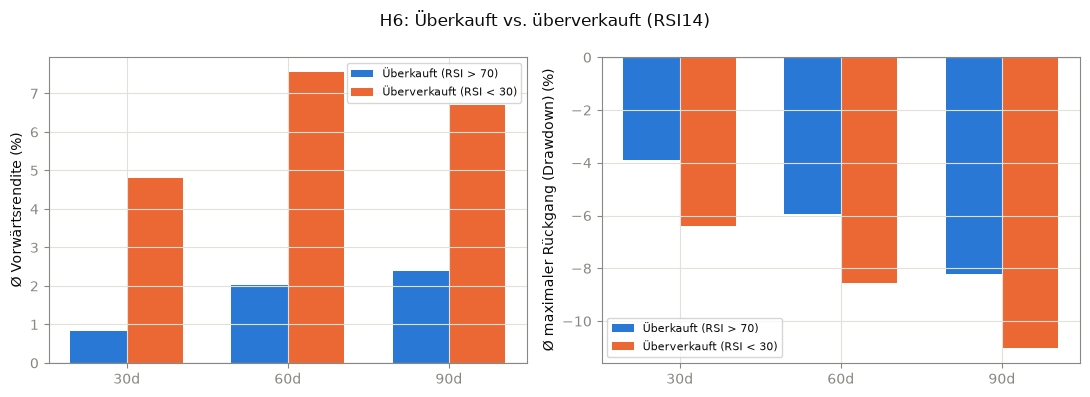

In [38]:
plotte_gruppenvergleich(tabelle_h6, "H6: Überkauft vs. überverkauft (RSI14)")


**Ergebnis:** Die klassische RSI-Interpretation bestätigt sich in den
vorliegenden Daten nicht. Nach überverkauften Phasen (RSI < 30) war die
mittlere Rendite in allen drei Horizonten signifikant höher als nach
überkauften Phasen (RSI > 70) (90 Tage: 6,7 % gegenüber 2,4 %); der
mittlere maximale Rückgang war zudem in den beiden kürzeren Horizonten (30
und 60 Tage) signifikant größer, beim 90-Tage-Horizont verfehlt der
Unterschied trotz vergleichbarer Größenordnung (−11,0 % gegenüber −8,2 %)
knapp die Signifikanzschwelle (Mann-Whitney-U-Test: p = 0,183).

**Praxisrelevanz für Börseninvestoren:** Ein stark überverkaufter Markt
sollte auf Basis dieser Daten nicht als "sichere Kaufgelegenheit"
interpretiert werden, wie es die klassische RSI-Lehrmeinung nahelegt –
tatsächlich war eine überverkaufte Marktlage historisch sowohl mit einer
höheren Rendite als auch, in den kürzeren Horizonten, mit einem höheren
Risiko verbunden. RSI eignet sich damit eher als Hinweis auf eine Phase
erhöhter Schwankungsbreite bei extremen Werten denn als eigenständiges
Umkehrsignal im klassischen Sinne.

### 4.7 Übergreifende Robustheitsübersicht

Zur zusammenfassenden Einordnung wird für jede Hypothese der Anteil der
getesteten Parameterkombinationen ausgewiesen, für den ein statistisch
signifikantes Ergebnis vorliegt – getrennt nach Rendite und Risiko.


In [39]:
# Anteil signifikanter Parameterkombinationen je Hypothese und Zielgröße -
# fasst die Robustheit über alle in Abschnitt 4 geprüften Parametrisierungen
# in einer einzigen Kennzahl zusammen.
robustheit = []
for name, tabelle in alle_ergebnisse.items():
    for ziel in ["fwd_return", "fwd_mdd"]:
        teil = tabelle[tabelle["zielgroesse"] == ziel]
        if len(teil) == 0:
            continue
        robustheit.append({
            "hypothese": name, "zielgroesse": ziel,
            "getestete_kombinationen": len(teil),
            "anteil_signifikant": teil["signifikant_5pct"].mean(),
        })

tabelle_robustheit = pd.DataFrame(robustheit)
pivot_robustheit = tabelle_robustheit.pivot(index="hypothese", columns="zielgroesse", values="anteil_signifikant")
pivot_robustheit = pivot_robustheit.rename(columns={"fwd_return": "Anteil signifikant (Rendite)",
                                                     "fwd_mdd": "Anteil signifikant (Risiko)"})
pivot_robustheit


zielgroesse,Anteil signifikant (Risiko),Anteil signifikant (Rendite)
hypothese,,
H1_Kurs_vs_SMA,1.0000,0.8889
H2_SMA_Richtung,1.0000,0.3333
H3_CrossOver,0.3333,0.0000
H4_Divergenz,0.0000,0.0000
H5_Drawdown_vom_Hoch,1.0000,1.0000
H6_Momentum_RSI,0.6667,1.0000


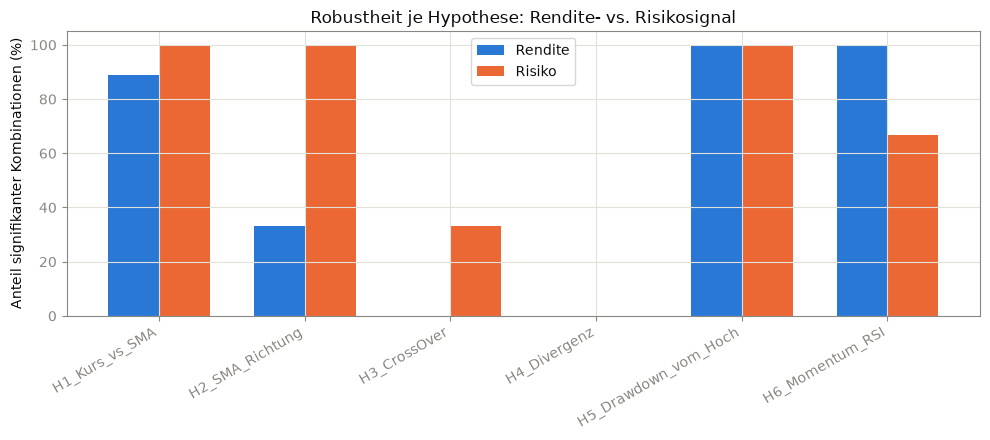

In [40]:
fig, achse = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(pivot_robustheit))
breite = 0.35
achse.bar(x - breite / 2, pivot_robustheit["Anteil signifikant (Rendite)"] * 100, breite, label="Rendite", color=COLOR_A)
achse.bar(x + breite / 2, pivot_robustheit["Anteil signifikant (Risiko)"] * 100, breite, label="Risiko", color=COLOR_B)
achse.set_xticks(x)
achse.set_xticklabels(pivot_robustheit.index, rotation=30, ha="right")
achse.set_ylabel("Anteil signifikanter Kombinationen (%)")
achse.legend()
plt.title("Robustheit je Hypothese: Rendite- vs. Risikosignal")
plt.tight_layout()
plt.show()


**Ergebnis:** Bei drei der sechs Hypothesen (H1, H2, H3) ist der Anteil
signifikanter Ergebnisse beim Risiko höher als bei der Rendite. Bei H4 und
H5 sind beide Anteile identisch (H4: 0 % in beiden Zielgrößen; H5: 100 %
in beiden Zielgrößen). Die einzige Hypothese, bei der die Rendite eine
höhere Signifikanzquote als das Risiko erreicht, ist H6 (RSI): Rendite in
100 % der getesteten Kombinationen signifikant, das Risiko dagegen nur in
67 %.

**Praxisrelevanz für Börseninvestoren:** Diese Übersicht relativiert den
naheliegenden Schluss, SMA-basierte Indikatoren seien grundsätzlich
bessere Risiko- als Renditeindikatoren: Für den Dow Jones gilt das klar
nur für H2 und H3, während H1 auch bei der Rendite eine hohe
Signifikanzquote (89 %) erreicht und H5 beide Zielgrößen durchgängig
(100 %) absichert. Für die Konstruktion eines Frühwarnsystems bedeutet
dies, dass insbesondere H1 und H5 sowohl als Risiko- als auch als
Renditeindikator brauchbare Evidenz liefern – wobei angesichts der in
Abschnitt 3.1 beschriebenen Einschränkung (Autokorrelation der
Handelstage) auch hier Vorsicht bei der Interpretation der exakten
p-Werte geboten bleibt.

## 5. Einordnung und Handlungsempfehlungen

| # | Hypothese | Eignung für ein Ampelsystem | Rolle |
|---|---|---|---|
| H1 | Kurs vs. SMA | Hoch (Risiko- und teilweise Renditeindikator) | Stabile Basis über alle drei Fenster, besonders SMA200 als Risikosignal |
| H2 | SMA-Richtung | Hoch (als Risikoindikator) | Ergänzt H1, eigenständiger Beitrag v. a. bei SMA20 |
| H3 | Cross-Over | Niedrig | Auf jeder Zeitbasis entweder zu selten oder nur teilweise signifikant |
| H4 | Divergenz | Niedrig | Nur D1 überhaupt testbar, ohne signifikanten Befund |
| H5 | Abstand vom Hoch | Hoch (als Risiko- und Renditeindikator) | Parameterfreie, gut kommunizierbare Zusatzstufe |
| H6 | Momentum (RSI) | Niedrig bis mittel | Risikohinweis in kürzeren Horizonten, kein Umkehrsignal |

**Zentraler Befund:** Bei H1, H2 und H5 ist das Risikosignal durchgängig
statistisch abgesichert; bei H1 und H5 zeigt sich zusätzlich auch ein
überwiegend bis durchgängig signifikantes Renditesignal, während sich die
Rendite-Risiko-Beziehung bei kurzen Zeitfenstern (SMA20, SMA100)
signifikant umkehrt (Mean-Reversion-Effekt). Die Ausweitung auf Wochen-
und Monatsbasis bei H3 und H4 zeigt zudem, dass längere Zeitbasen nicht
automatisch aussagekräftigere Signale liefern, sondern vor allem die
Ereignisanzahl reduzieren und dadurch die statistische Testbarkeit
einschränken.

**Empfehlung:** Ein Ampelsystem sollte primär als **Risikoindikator**
konzipiert werden, gestützt auf H1 und H2 (Trendposition und -richtung,
mit SMA200 als stabiler Basis) sowie H5 (Drawdown-Status als objektive,
parameterfreie Zusatzstufe, die zugleich ein robustes Renditesignal
liefert). H3, H4 und H6 liefern ergänzende, aber keine tragfähigen
Kernbausteine.

## 6. Ampel-Systematik: Kategoriendefinition und Validierung

Die Einordnung in Abschnitt 5 identifiziert die Trendposition und -richtung
relativ zum SMA200 (H1, H2) sowie den Abstand vom bisherigen Hoch (H5) als
die robustesten Risikosignale der gesamten Analyse. Dieser Abschnitt leitet
daraus eine konkrete, dreistufige Ampel-Kategorisierung (Grün/Gelb/Rot) ab
und validiert sie mit derselben statistischen Methodik wie die
vorangegangenen Hypothesentests.

Bewusst nicht als Kernbaustein verwendet werden H3 (Cross-Over) und H4
(Divergenz): Beide liefern für die meisten geprüften Parametrisierungen zu
wenige Ereignisse für eine belastbare Kalibrierung (Abschnitt 4.3 und 4.4).
H6 (RSI) fließt als ergänzender Hinweis ein, wird aber nicht Teil der
Kernregel, da das zugehörige Risikosignal zwar vorhanden, aber weniger
konsistent abgesichert ist als bei H1, H2 und H5 (Abschnitt 4.7).


### 6.1 Bausteine: Trend-Score (H1 + H2) und Drawdown-Stufe (H5)

Aus H1 und H2 wird ein dreistufiger **Trend-Score** auf Basis des SMA200
gebildet, der beide Signale kombiniert:

- **0 Punkte:** Kurs notiert über dem SMA200 **und** dieser steigt
  gleichzeitig (eindeutig bullische Lage).
- **1 Punkt:** genau eine der beiden Bedingungen ist erfüllt (gemischte Lage).
- **2 Punkte:** Kurs notiert unter dem SMA200 **und** dieser fällt
  gleichzeitig (eindeutig bärische Lage).

Die bereits in Abschnitt 4.5 eingeführte **Drawdown-Stufe**
(`Drawdown_Bucket`) wird unverändert als zweiter Baustein übernommen.


In [41]:
def trend_score(kurs_ueber_sma: pd.Series, sma_steigend: pd.Series) -> pd.Series:
    # 0 = beide Bedingungen bullisch, 2 = beide bärisch, 1 = gemischt.
    # Tage ohne gültigen SMA200-Wert (Anfang der Zeitreihe) bleiben NaN.
    valide = kurs_ueber_sma.notna() & sma_steigend.notna()
    score = pd.Series(np.nan, index=df.index)
    score[valide & kurs_ueber_sma & sma_steigend] = 0
    score[valide & (kurs_ueber_sma != sma_steigend)] = 1
    score[valide & ~kurs_ueber_sma & ~sma_steigend] = 2
    return score


kurs_ueber_sma200 = df["Close"] > df["SMA200_d"]
sma200_steigend = df["SMA200_d"].diff() > 0
df["Trend_Score"] = trend_score(kurs_ueber_sma200, sma200_steigend)

print("Verteilung des Trend-Score (0 = bullisch, 2 = bärisch):")
print(df["Trend_Score"].value_counts().sort_index())


Verteilung des Trend-Score (0 = bullisch, 2 = bärisch):
Trend_Score
0.0000    3355
1.0000     530
2.0000    1045
Name: count, dtype: int64


### 6.2 Empirische Grundlage der Kategoriengrenzen

Um die Zuordnung der zwölf Kombinationen aus Trend-Score (0 bis 2) und
Drawdown-Stufe (vier Stufen) zu den drei Ampelfarben nicht willkürlich zu
setzen, wird für jede Kombination der mittlere 90-Tage-Vorwärts-Drawdown
(`fwd_mdd_90d`) ausgewiesen – die Kennzahl, die laut Abschnitt 4.7 über
alle Hypothesen hinweg das robustere Signal liefert.


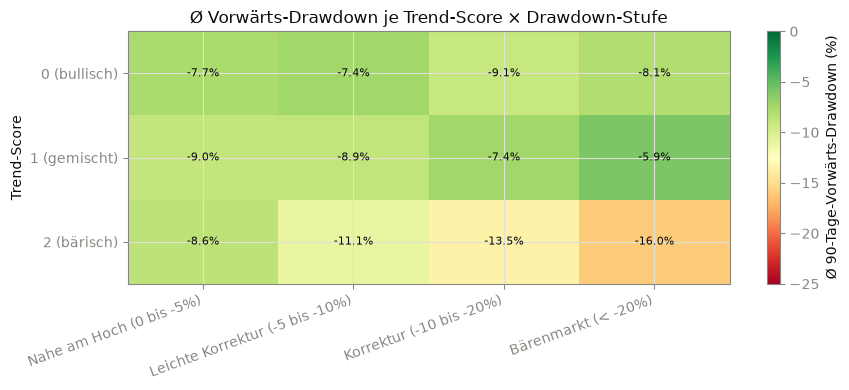

Drawdown_Bucket,Nahe am Hoch (0 bis -5%),Leichte Korrektur (-5 bis -10%),Korrektur (-10 bis -20%),Bärenmarkt (< -20%)
Trend_Score,,,,
0.0000,-0.0772,-0.0737,-0.0914,-0.0810
1.0000,-0.0898,-0.0886,-0.0741,-0.0592
2.0000,-0.0862,-0.1107,-0.1354,-0.1596


In [42]:
heatmap_basis = df.groupby(["Trend_Score", "Drawdown_Bucket"])["fwd_mdd_90d"].mean().unstack()
heatmap_basis = heatmap_basis[bucket_reihenfolge]

fig, achse = plt.subplots(figsize=(9, 4))
bild = achse.imshow(heatmap_basis.values * 100, cmap="RdYlGn", aspect="auto", vmin=-25, vmax=0)
achse.set_xticks(range(len(bucket_reihenfolge)))
achse.set_xticklabels(bucket_reihenfolge, rotation=20, ha="right")
achse.set_yticks(range(3))
achse.set_yticklabels(["0 (bullisch)", "1 (gemischt)", "2 (bärisch)"])
achse.set_ylabel("Trend-Score")
for i in range(heatmap_basis.shape[0]):
    for j in range(heatmap_basis.shape[1]):
        wert = heatmap_basis.values[i, j]
        if not np.isnan(wert):
            achse.text(j, i, f"{wert * 100:.1f}%", ha="center", va="center", fontsize=8)
fig.colorbar(bild, ax=achse, label="Ø 90-Tage-Vorwärts-Drawdown (%)")
plt.title("Ø Vorwärts-Drawdown je Trend-Score × Drawdown-Stufe")
plt.tight_layout()
plt.show()
heatmap_basis


**Ergebnis:** Die Heatmap zeigt ein klares Muster: Bei Trend-Score 2 (Kurs
unter fallendem SMA200) liegt der mittlere 90-Tage-Vorwärts-Drawdown in
den beiden tieferen Drawdown-Stufen bei rund −13,5 % bis −16,0 % und
damit deutlich höher als in jeder anderen Kombination; bei Trend-Score 0
(Kurs über steigendem SMA200) liegt er in den beiden flacheren Stufen bei
rund −7,4 % bis −7,7 % und damit am niedrigsten. Die Zwischenstufe
(Trend-Score 1) liegt überwiegend dazwischen, mit einzelnen
unregelmäßigen Werten – u. a. einem vergleichsweise niedrigen Wert von
−5,9 % in der Bärenmarkt-Stufe –, die auf die dort deutlich kleinere
Stichprobe (530 von 4.930 Handelstagen) zurückgehen. Diese Struktur
bestätigt empirisch, dass die Regel „beide Bausteine übereinstimmend
günstig = Grün, beide übereinstimmend ungünstig = Rot" sinnvoll kalibriert
ist.

### 6.3 Kategorienregel

Auf Basis der Heatmap in 6.2 werden die zwölf Kombinationen den drei
Ampelfarben zugeordnet: **Grün**, wenn Trend-Score und Drawdown-Stufe
übereinstimmend ein günstiges Bild zeichnen; **Rot**, wenn beide
übereinstimmend ein ungünstiges Bild zeichnen; **Gelb** für alle gemischten
Fälle dazwischen. Diese Regel überträgt damit unmittelbar das in Abschnitt
4.7 dokumentierte Muster auf die Kategorienbildung: Risikosignale sind bei
H1, H2 und H5 am robustesten abgesichert, wenn sie übereinstimmend in
dieselbe Richtung weisen.


In [43]:
def ampel_farbe(trend_score: float, drawdown_bucket: str) -> str:
    bullisch = trend_score == 0
    baerisch = trend_score == 2
    tief = drawdown_bucket in ("Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)")
    flach = drawdown_bucket in ("Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)")

    if bullisch and flach:
        return "Grün"
    if baerisch and tief:
        return "Rot"
    return "Gelb"


df["Ampel"] = [
    ampel_farbe(ts, db) if pd.notna(ts) else np.nan
    for ts, db in zip(df["Trend_Score"], df["Drawdown_Bucket"])
]

print("Verteilung der Handelstage auf die drei Ampelfarben:")
print(df["Ampel"].value_counts().reindex(["Grün", "Gelb", "Rot"]))


Verteilung der Handelstage auf die drei Ampelfarben:
Ampel
Grün    2819
Gelb    1413
Rot      698
Name: count, dtype: int64


### 6.4 Statistische Validierung der Ampelfarben

Analog zu den Hypothesentests in Abschnitt 4 werden die drei Ampelfarben
paarweise mit `vergleiche_gruppen()` auf Vorwärtsrendite und -drawdown
verglichen.


In [44]:
ampel_farben = ["Grün", "Gelb", "Rot"]
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]

ergebnisse_ampel = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgroesse": ziel})
                ergebnisse_ampel.append(res)

tabelle_ampel = ergebnisse_zu_tabelle(ergebnisse_ampel)
tabelle_ampel[["vergleich", "horizont_tage", "zielgroesse", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]]


,vergleich,horizont_tage,zielgroesse,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0084,0.0094,0.5342,0.0017,False
1,Grün vs. Gelb,30,fwd_mdd,-0.0397,-0.0521,0.0000,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0168,0.0237,0.0004,0.0000,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0608,-0.0739,0.0000,0.0000,True
4,Grün vs. Gelb,90,fwd_return,0.0285,0.0345,0.0095,0.0173,True
5,Grün vs. Gelb,90,fwd_mdd,-0.0766,-0.0874,0.0000,0.0000,True
6,Gelb vs. Rot,30,fwd_return,0.0094,0.0195,0.0050,0.0000,True
7,Gelb vs. Rot,30,fwd_mdd,-0.0521,-0.0810,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0237,0.0271,0.4928,0.0000,False
9,Gelb vs. Rot,60,fwd_mdd,-0.0739,-0.1176,0.0000,0.0000,True


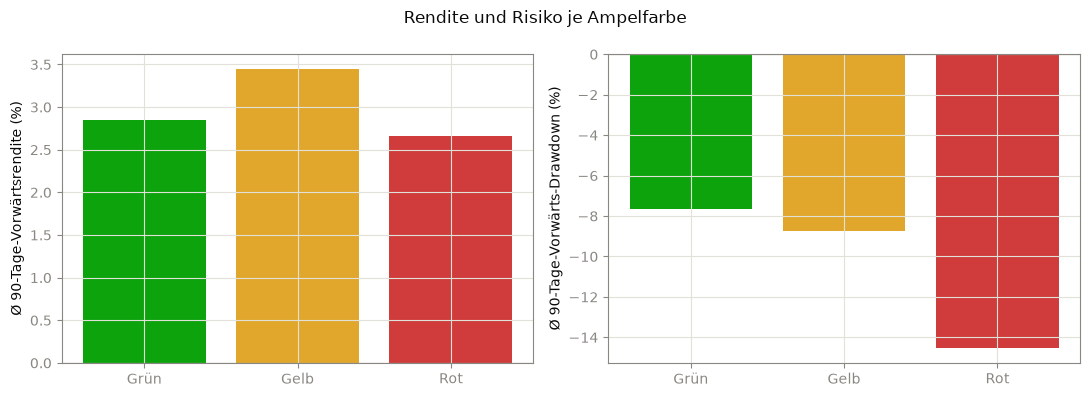

In [45]:
mittelwerte_ampel = df.groupby("Ampel")[["fwd_return_90d", "fwd_mdd_90d"]].mean().reindex(ampel_farben)
ampel_farbcodes = {"Grün": COLOR_GOOD, "Gelb": COLOR_WARN, "Rot": COLOR_BAD}

fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
for achse, spalte, titel in zip(achsen, ["fwd_return_90d", "fwd_mdd_90d"],
                                 ["Ø 90-Tage-Vorwärtsrendite", "Ø 90-Tage-Vorwärts-Drawdown"]):
    achse.bar(mittelwerte_ampel.index, mittelwerte_ampel[spalte] * 100,
              color=[ampel_farbcodes[f] for f in mittelwerte_ampel.index])
    achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
    achse.set_ylabel(f"{titel} (%)")
fig.suptitle("Rendite und Risiko je Ampelfarbe")
fig.tight_layout()
plt.show()


**Ergebnis:** Die drei Ampelfarben trennen das Risiko klar und
durchgängig signifikant: Der mittlere Vorwärts-Drawdown steigt monoton
von Grün (−4,0 % / −6,1 % / −7,7 % über 30/60/90 Tage) über Gelb
(−5,2 % / −7,4 % / −8,7 %) zu Rot (−8,1 % / −11,8 % / −14,5 %) – alle
neun Risikovergleiche (drei Farbpaare × drei Horizonte) sind statistisch
signifikant. Bei der Rendite ist das Bild gemischter: Signifikant sind
die Unterschiede zwischen Grün und Gelb bei 60 und 90 Tagen, zwischen
Gelb und Rot beim 30-Tage-Horizont sowie zwischen Grün und Rot bei 30 und
60 Tagen; bei den übrigen vier Kombinationen – darunter Grün gegenüber
Rot im 90-Tage-Horizont, wo beide Gruppen mit 2,9 % bzw. 2,7 % nahe
beieinanderliegen – ist kein Renditeunterschied statistisch abgesichert.

**Praxisrelevanz für Börseninvestoren:** Die Ampel funktioniert damit
erwartungsgemäß in erster Linie als Risikoindikator. Das Renditesignal ist
zwar in gut der Hälfte der geprüften Kombinationen statistisch
nachweisbar, jedoch nicht durchgängig und insbesondere im längsten
Horizont zwischen Grün und Rot nicht mehr signifikant – für
Anlageentscheidungen sollte die Ampel daher primär als Risikofilter, nicht
als verlässliches Renditesignal verstanden werden.

### 6.5 Ergänzende Rolle von H6 (RSI)

Der RSI wird nicht in die Kernregel aufgenommen, da das zugehörige
Risikosignal in Abschnitt 4.6 zwar in zwei von drei Horizonten signifikant
ist, jedoch schwächer abgesichert ist als bei H1, H2 und H5 und zudem eine
kontraintuitive Richtung aufweist: Überverkaufte Phasen (RSI < 30) trugen
historisch das höhere Risiko, nicht überkaufte Phasen. Für die Praxis
bedeutet dies, dass ein stark überverkaufter RSI innerhalb einer
Gelb-Phase als zusätzlicher Hinweis auf eine mögliche Verschärfung Richtung
Rot gelesen werden kann, ohne dass der RSI allein eine Kategorie bestimmt.


### 6.6 Ampel-Hintergrund im Kursverlauf

Die folgende Darstellung überträgt die Kategorienregel auf den gesamten
Analysezeitraum und macht sichtbar, wie sich Grün-, Gelb- und Rot-Phasen im
historischen Kursverlauf verteilen. Abschnitt 7 untersucht anschließend,
welche Rendite- und Risikowirkung ein Ausschluss der Rot-Phasen gehabt
hätte.


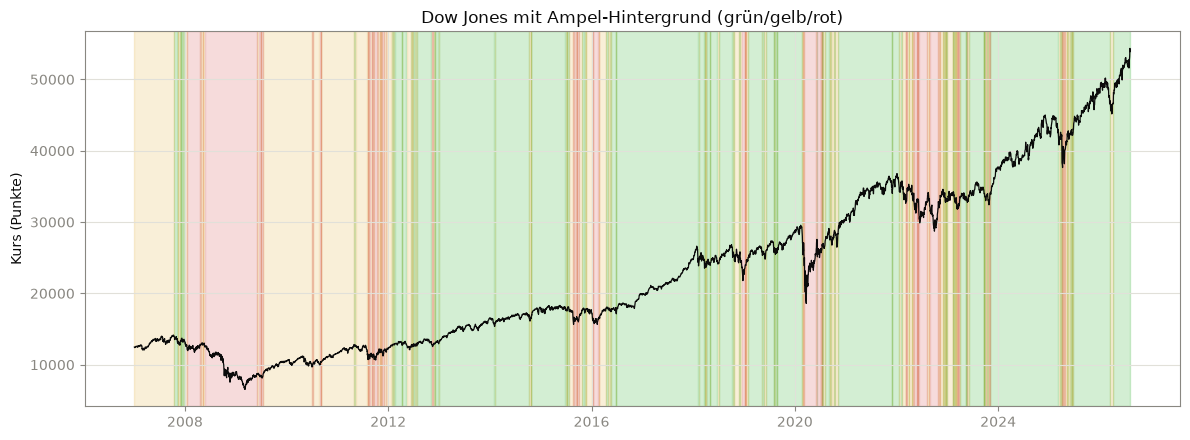

In [46]:
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in ampel_farben:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=ampel_farbcodes[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title("Dow Jones mit Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()


## 7. Was-wäre-wenn-Analyse: Wirkung des Risikophasen-Ausschlusses

Die Hypothesentests in Abschnitt 4 verwenden vorwärtsgerichtete Zielgrößen
(`fwd_return`, `fwd_mdd`) ausschließlich zur Signifikanzprüfung – sie
beantworten, ob ein Regimezustand statistisch mit einer anderen
Folgeperiode einhergeht, nicht, was ein regelbasiertes Investment ergeben
hätte. Dieser Abschnitt nimmt die zweite Perspektive ein: Für jede
Hypothese, bei der sich ein anhaltender Regimezustand definieren lässt,
wird simuliert, wie sich Gesamtrendite, annualisierte Rendite (CAGR) und
maximaler Drawdown verändert hätten, wenn an Tagen mit dem jeweils
ungünstigeren Regimezustand nicht investiert gewesen wäre.

**Methodische Abgrenzung:** Anders als die Vorwärtsgrößen in Abschnitt 4
verwendet diese Analyse ausschließlich den zum jeweiligen Zeitpunkt bereits
bekannten Regimezustand (z. B. „Kurs notiert heute unter dem SMA200") und
keine zukünftigen Informationen – die Simulation ist damit frei von
Rückschaufehlern (Look-ahead-Bias) im Sinne einer nachvollziehbaren
Handelsregel. Vereinfachend werden Transaktionskosten und eine Verzinsung
der Cash-Position an ausgeschlossenen Tagen nicht berücksichtigt.

**H4 (Divergenz) wird bewusst ausgeschlossen:** D1 und D2 sind seltene
Punktereignisse (15 bzw. 2 Fälle seit 2007) ohne anhaltenden
Regimezustand – daraus lässt sich keine Phase ableiten, die über einen
längeren Zeitraum „ausgeschlossen" werden könnte.


### 7.1 Backtest-Hilfsfunktionen


In [47]:
def historischer_max_drawdown(werte: pd.Series) -> float:
    # Klassischer Peak-to-Trough-Drawdown einer (kumulierten) Wertreihe -
    # im Unterschied zu forward_max_drawdown rückblickend über die gesamte Reihe.
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_waere_wenn(schlecht: pd.Series, label: str) -> dict:
    # Simuliert eine Strategie, die an "schlecht" markierten Tagen in Cash
    # geht (Tagesrendite 0, ohne Cash-Verzinsung und Transaktionskosten) und
    # ansonsten voll investiert ist - und vergleicht das Ergebnis mit Buy & Hold.
    tagesrendite = df["Close"].pct_change().fillna(0)
    schlecht_bereinigt = schlecht.reindex(df.index).fillna(False)

    strategie_rendite = tagesrendite.where(~schlecht_bereinigt, 0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity: pd.Series) -> tuple[float, float, float]:
        gesamtrendite = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamtrendite, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "hypothese": label,
        "anteil_schlecht_tage": schlecht_bereinigt.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Backtest-Hilfsfunktionen definiert.")


Backtest-Hilfsfunktionen definiert.


### 7.2 Regime-Definitionen je Hypothese

Für jede einbezogene Hypothese wird der „schlechte" (auszuschließende)
Regimezustand aus den bereits berechneten Spalten abgeleitet:

- **H1** (SMA20/100/200): Kurs notiert unter dem jeweiligen SMA.
- **H2** (SMA20/100/200): der jeweilige SMA fällt.
- **H3** (nur die beiden testbaren Tagesbasis-Paare SMA20/100 und
  SMA20/200): Regime zwischen Golden und Death Cross, durch Fortschreibung
  der Kreuzungsereignisse gebildet; „schlecht" = Zustand seit dem letzten
  Death Cross.
- **H5**: Drawdown-Stufe „Korrektur" oder „Bärenmarkt" (mindestens 10 %
  unter dem bisherigen Hoch).
- **H6**: RSI < 30 (überverkauft) – bewusst nicht die klassische
  „RSI > 70 = riskant"-Lesart, da Abschnitt 4.6 zeigt, dass überverkaufte
  Phasen historisch das höhere Risiko trugen.
- **Kombinierte Ampel** (Abschnitt 6): Rot-Tage.


In [48]:
def crossover_regime_schlecht(golden: pd.Series, death: pd.Series) -> pd.Series:
    # Bildet einen anhaltenden Regimezustand aus den punktuellen Kreuzungs-
    # ereignissen: "schlecht" gilt ab einem Death Cross, bis der nächste
    # Golden Cross eintritt (Fortschreibung per ffill).
    ereignis = pd.Series(np.nan, index=df.index, dtype="object")
    ereignis[golden] = False
    ereignis[death] = True
    return ereignis.ffill().fillna(False).astype(bool)


regime_definitionen: dict[str, pd.Series] = {}

for w in SMA_WINDOWS_DAILY:
    ueber, _ = regime_gruppen(w)
    regime_definitionen[f"H1_SMA{w}"] = ~ueber.reindex(df.index).fillna(False)

for w in SMA_WINDOWS_DAILY:
    steigend, _ = regime_gruppen_richtung(w)
    regime_definitionen[f"H2_SMA{w}"] = ~steigend.reindex(df.index).fillna(False)

for kurz, lang in [(20, 100), (20, 200)]:
    golden, death = finde_crossover(df[f"SMA{kurz}_d"], df[f"SMA{lang}_d"])
    regime_definitionen[f"H3_SMA{kurz}_{lang}"] = crossover_regime_schlecht(golden, death)

regime_definitionen["H5_Drawdown"] = df["Drawdown_Bucket"].isin(
    ["Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]
)
regime_definitionen["H6_RSI_ueberverkauft"] = df["RSI14"] < 30
regime_definitionen["Ampel_Rot"] = df["Ampel"] == "Rot"

print("Regime-Definitionen für die Was-wäre-wenn-Analyse:", list(regime_definitionen.keys()))


Regime-Definitionen für die Was-wäre-wenn-Analyse: ['H1_SMA20', 'H1_SMA100', 'H1_SMA200', 'H2_SMA20', 'H2_SMA100', 'H2_SMA200', 'H3_SMA20_100', 'H3_SMA20_200', 'H5_Drawdown', 'H6_RSI_ueberverkauft', 'Ampel_Rot']


### 7.3 Konsolidierte Kennzahlenübersicht

Für alle elf Parametrisierungen werden Gesamtrendite, CAGR und maximaler
Drawdown von Buy & Hold der jeweiligen Ausschluss-Strategie
gegenübergestellt.


In [49]:
ergebnisse_www = [was_waere_wenn(schlecht, name) for name, schlecht in regime_definitionen.items()]
tabelle_was_waere_wenn = pd.DataFrame(ergebnisse_www).drop(columns=["equity_buy_hold", "equity_strategie"])
tabelle_was_waere_wenn


,hypothese,anteil_schlecht_tage,gesamtrendite_buy_hold,cagr_buy_hold,max_drawdown_buy_hold,gesamtrendite_strategie,cagr_strategie,max_drawdown_strategie
0,H1_SMA20,0.3700,3.3318,0.0777,-0.5378,"1,987.1747",0.4735,-0.0508
1,H1_SMA100,0.3097,3.3318,0.0777,-0.5378,53.9027,0.2268,-0.0927
2,H1_SMA200,0.2722,3.3318,0.0777,-0.5378,19.7797,0.1675,-0.1158
3,H2_SMA20,0.3609,3.3318,0.0777,-0.5378,146.5167,0.2903,-0.0886
4,H2_SMA100,0.2970,3.3318,0.0777,-0.5378,13.8683,0.1477,-0.1158
5,H2_SMA200,0.2592,3.3318,0.0777,-0.5378,8.8584,0.1239,-0.1314
6,H3_SMA20_100,0.2866,3.3318,0.0777,-0.5378,1.3191,0.0439,-0.2561
7,H3_SMA20_200,0.2274,3.3318,0.0777,-0.5378,3.3570,0.0780,-0.1929
8,H5_Drawdown,0.2848,3.3318,0.0777,-0.5378,11.8639,0.1393,-0.0997
9,H6_RSI_ueberverkauft,0.0207,3.3318,0.0777,-0.5378,25.6305,0.1824,-0.3361


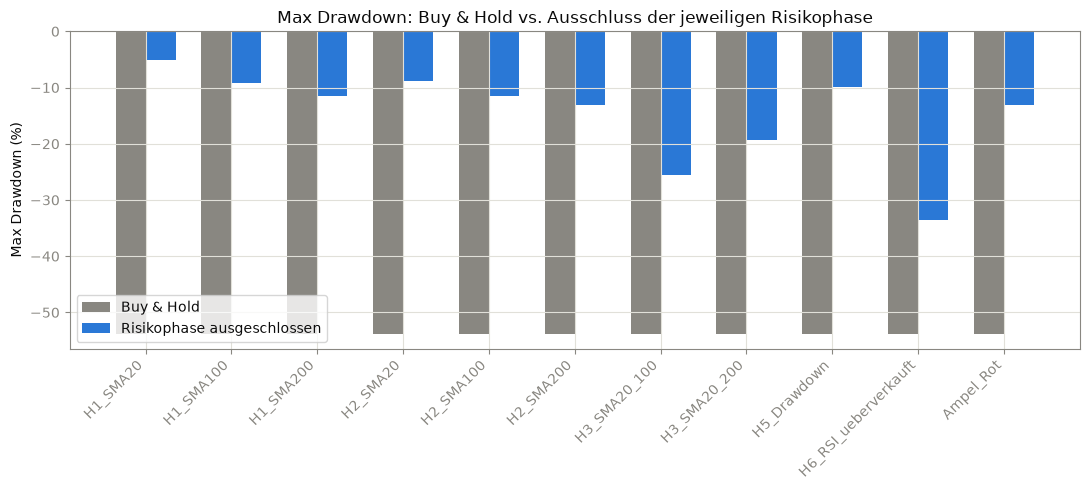

In [50]:
fig, achse = plt.subplots(figsize=(11, 5))
x = np.arange(len(tabelle_was_waere_wenn))
breite = 0.35
achse.bar(x - breite / 2, tabelle_was_waere_wenn["max_drawdown_buy_hold"] * 100, breite,
          label="Buy & Hold", color=COLOR_MUTED)
achse.bar(x + breite / 2, tabelle_was_waere_wenn["max_drawdown_strategie"] * 100, breite,
          label="Risikophase ausgeschlossen", color=COLOR_A)
achse.set_xticks(x)
achse.set_xticklabels(tabelle_was_waere_wenn["hypothese"], rotation=45, ha="right")
achse.set_ylabel("Max Drawdown (%)")
achse.legend()
plt.title("Max Drawdown: Buy & Hold vs. Ausschluss der jeweiligen Risikophase")
plt.tight_layout()
plt.show()


**Ergebnis:** Über alle elf Parametrisierungen hinweg reduziert der
Ausschluss der jeweils definierten Risikophase den Max Drawdown gegenüber
Buy & Hold (−53,8 %) durchgängig, bei acht der elf Parametrisierungen auf
einen Bereich von rund −5 % bis −14 %. Zwei Ausnahmen bestätigen den in
Abschnitt 4.3 dokumentierten Befund: Bei den beiden Cross-Over-Paaren (H3)
bleibt der Max Drawdown mit −25,6 % (SMA20/100) bzw. −19,3 % (SMA20/200)
deutlich höher als bei den übrigen Hypothesen, und die annualisierte
Rendite liegt mit 4,4 % bzw. 7,8 % unterhalb bzw. auf Höhe der
Buy-&-Hold-CAGR von 7,8 % – ein Ausschluss auf Basis eines nicht
durchgängig signifikanten Signals (siehe 4.3) verbessert hier das
Chance-Risiko-Verhältnis kaum bis gar nicht. Am auffälligsten ist H6 (RSI
< 30): Der Ausschluss von nur 2,1 % der Handelstage senkt den Max Drawdown
bereits von −53,8 % auf −33,6 % – ein Beleg dafür, dass sich extreme
Überverkauft-Phasen zeitlich eng mit den größten Kurseinbrüchen
überschneiden, auch wenn der resultierende Max Drawdown mit −33,6 %
deutlich höher bleibt als bei den übrigen, trägeren Parametrisierungen.

**Praxisrelevanz für Börseninvestoren:** Die stärksten CAGR-Verbesserungen
zeigen sich bei den schnellsten Parametrisierungen (H1/H2 mit SMA20: CAGR
47,4 % bzw. 29,0 %), die allein aufgrund ihrer hohen
Reaktionsgeschwindigkeit einen großen Anteil der Verlusttage vermeiden. Da
die Simulation weder Transaktionskosten noch Slippage berücksichtigt
(siehe methodische Abgrenzung zu Beginn von Abschnitt 7) und ein
SMA20-Signal in der Praxis sehr häufig wechselt, sind diese Werte mit
erheblicher Vorsicht zu interpretieren: Sie zeigen das theoretische
Potenzial einer regelbasierten Risikosteuerung, nicht die realistisch
erzielbare Rendite einer handelbaren Strategie. Die trägeren, robusteren
Parametrisierungen (SMA200, Drawdown-Stufe, kombinierte Ampel) liefern mit
CAGR-Werten zwischen rund 12 % und 17 % bei gleichzeitig deutlich
reduziertem Max Drawdown (rund −10 % bis −13 %) ein realistischeres Bild
des Nutzens einer Ampel-gestützten Risikosteuerung.

### 7.4 Vertiefte Einzelbetrachtung

Für sechs repräsentative Fälle wird zusätzlich der zeitliche Verlauf
dargestellt: oben der Kursverlauf mit rot hinterlegter Ausschlussphase,
darunter die Wertentwicklung von Buy & Hold gegenüber der
Ausschluss-Strategie (logarithmische Skala, Startwert = 1).


In [51]:
def plotte_was_waere_wenn(name: str, schlecht: pd.Series, titel: str) -> dict:
    ergebnis = was_waere_wenn(schlecht, name)
    schlecht_reindiziert = schlecht.reindex(df.index).fillna(False)

    fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                             transform=achse_kurs.get_xaxis_transform())
    achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
    achse_kurs.set_ylabel("Kurs (Punkte)")
    achse_kurs.set_title(f"{titel} – rot hinterlegt: ausgeschlossene Risikophase")

    achse_equity.plot(df.index, ergebnis["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
    achse_equity.plot(df.index, ergebnis["equity_strategie"], color=COLOR_A, label="Risikophase ausgeschlossen")
    achse_equity.set_yscale("log")
    achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
    achse_equity.legend()

    fig.tight_layout()
    plt.show()

    print(f"Anteil ausgeschlossener Handelstage: {ergebnis['anteil_schlecht_tage']:.1%}")
    print(f"Gesamtrendite  - Buy & Hold: {ergebnis['gesamtrendite_buy_hold']:.1%} | Ausschluss: {ergebnis['gesamtrendite_strategie']:.1%}")
    print(f"CAGR           - Buy & Hold: {ergebnis['cagr_buy_hold']:.1%} | Ausschluss: {ergebnis['cagr_strategie']:.1%}")
    print(f"Max Drawdown   - Buy & Hold: {ergebnis['max_drawdown_buy_hold']:.1%} | Ausschluss: {ergebnis['max_drawdown_strategie']:.1%}")
    return ergebnis


#### H1 – Kurs unter SMA200 ausgeschlossen


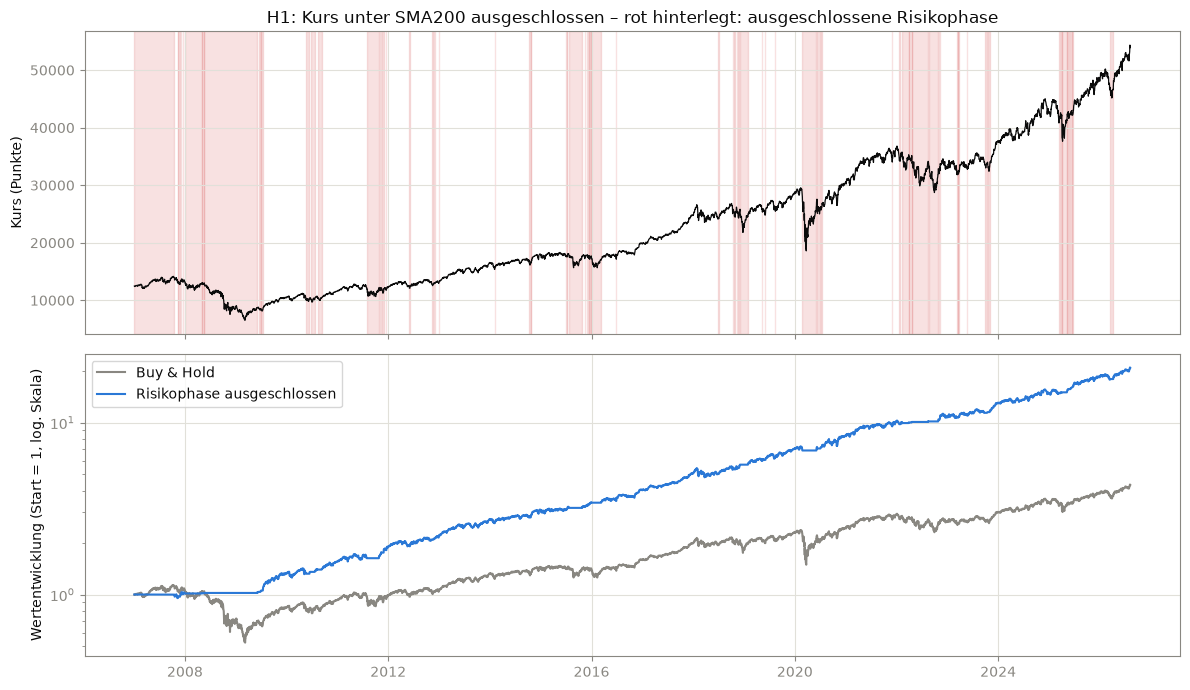

Anteil ausgeschlossener Handelstage: 27.2%
Gesamtrendite  - Buy & Hold: 333.2% | Ausschluss: 1978.0%
CAGR           - Buy & Hold: 7.8% | Ausschluss: 16.7%
Max Drawdown   - Buy & Hold: -53.8% | Ausschluss: -11.6%


In [52]:
_ = plotte_was_waere_wenn("H1_SMA200", regime_definitionen["H1_SMA200"], "H1: Kurs unter SMA200 ausgeschlossen")


**Ergebnis:** Der Ausschluss der 27,2 % Handelstage, an denen der Kurs
unter dem SMA200 notiert, senkt den Max Drawdown von −53,8 % (Buy & Hold)
auf −11,6 % und erhöht die CAGR von 7,8 % auf 16,7 %. Dies bestätigt
quantitativ, warum H1/SMA200 in den Abschnitten 4.1 und 5 als robuster
Kernbaustein der Ampel identifiziert wurde.

**Praxisrelevanz für Börseninvestoren:** Das obere Diagramm zeigt, dass
sich die rot hinterlegten Phasen mit den bereits in Abschnitt 4.1
dokumentierten längeren Bärenmarktphasen decken. Ein Investor, der
ausschließlich bei Kurs über SMA200 investiert gewesen wäre, hätte
historisch einen erheblichen Teil des maximalen Verlusts vermieden –
allerdings ohne Berücksichtigung von Transaktionskosten und mit dem
Risiko einzelner Fehlsignale bei kurzen Regimewechseln (siehe
Regime-Laufzeiten in Abschnitt 4.1, mediane Phasendauer von nur 4 bzw. 5
Handelstagen).

#### H2 – Fallende SMA200-Richtung ausgeschlossen


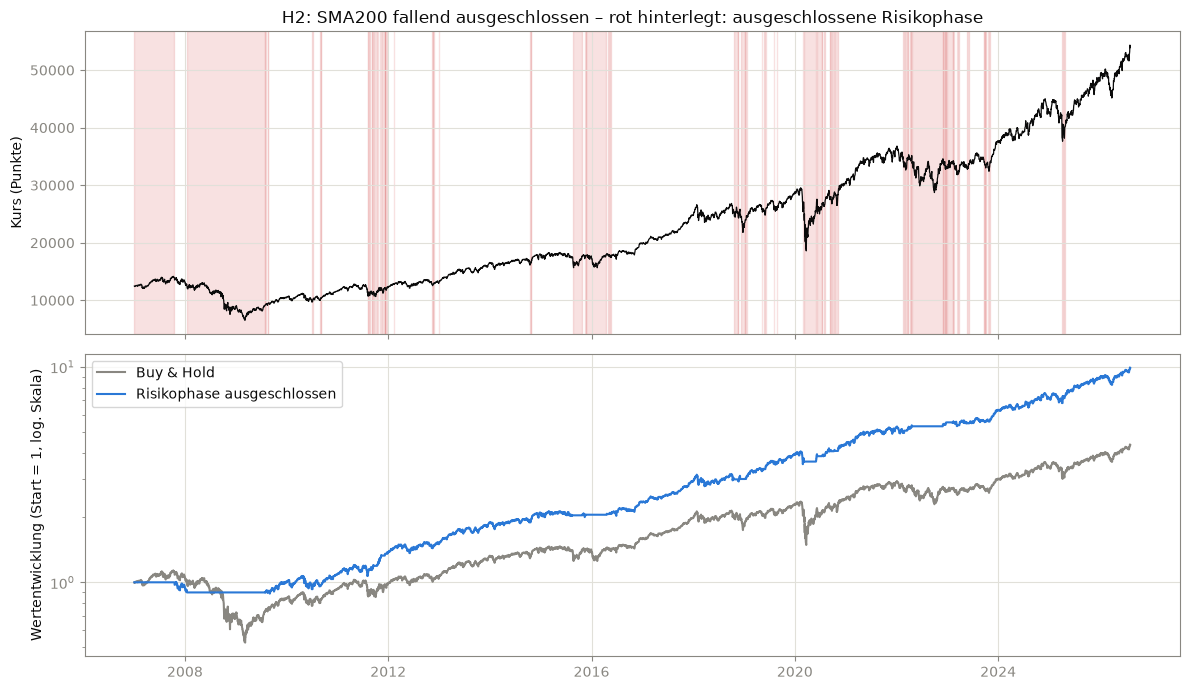

Anteil ausgeschlossener Handelstage: 25.9%
Gesamtrendite  - Buy & Hold: 333.2% | Ausschluss: 885.8%
CAGR           - Buy & Hold: 7.8% | Ausschluss: 12.4%
Max Drawdown   - Buy & Hold: -53.8% | Ausschluss: -13.1%


In [53]:
_ = plotte_was_waere_wenn("H2_SMA200", regime_definitionen["H2_SMA200"], "H2: SMA200 fallend ausgeschlossen")


**Ergebnis:** Der Ausschluss der 25,9 % Handelstage mit fallendem SMA200
senkt den Max Drawdown von −53,8 % auf −13,1 % und erhöht die CAGR von
7,8 % auf 12,4 % – eine spürbare, wenn auch etwas schwächere Verbesserung
als bei H1/SMA200.

**Praxisrelevanz für Börseninvestoren:** Da SMA200-Position (H1) und
-Richtung (H2) laut Abschnitt 6.1 stark korrelieren, überrascht die
ähnliche Grundtendenz nicht; die etwas geringere Verbesserung bei H2
spiegelt wider, dass die Richtung träger auf Trendwenden reagiert als die
reine Positionsfrage.

#### H3 – Death-Cross-Regime (SMA20/200) ausgeschlossen


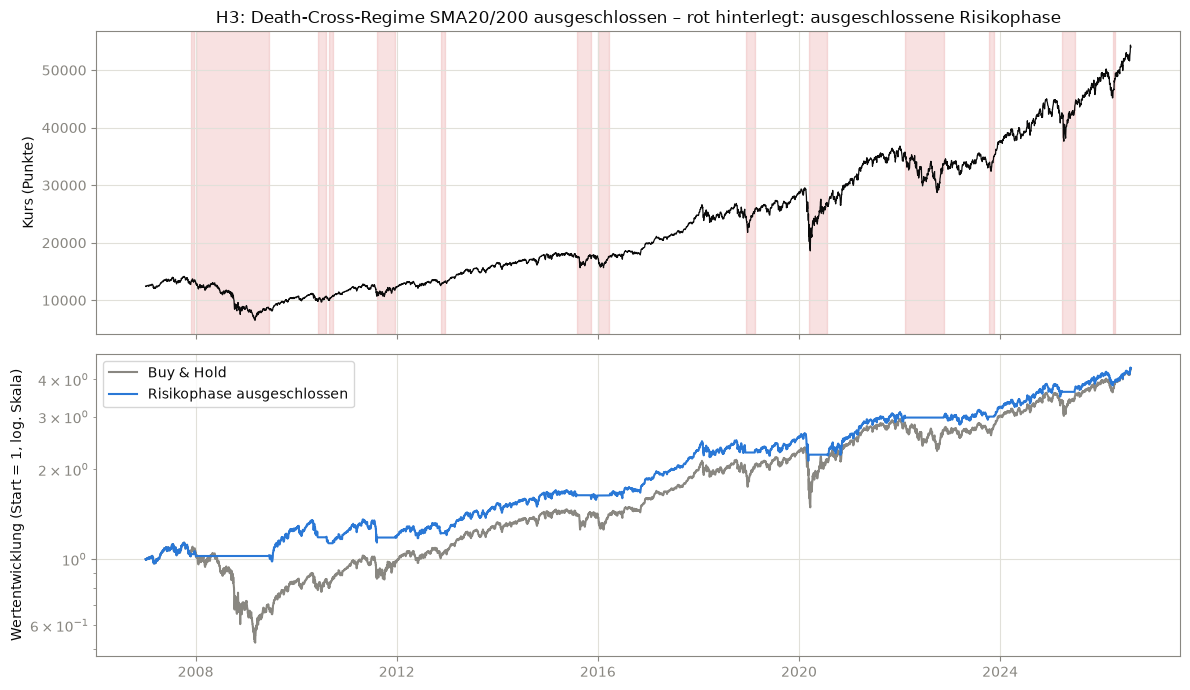

Anteil ausgeschlossener Handelstage: 22.7%
Gesamtrendite  - Buy & Hold: 333.2% | Ausschluss: 335.7%
CAGR           - Buy & Hold: 7.8% | Ausschluss: 7.8%
Max Drawdown   - Buy & Hold: -53.8% | Ausschluss: -19.3%


In [54]:
_ = plotte_was_waere_wenn("H3_SMA20_200", regime_definitionen["H3_SMA20_200"], "H3: Death-Cross-Regime SMA20/200 ausgeschlossen")


**Ergebnis:** Der Ausschluss der 22,7 % Handelstage im Death-Cross-Regime
(SMA20/200) senkt den Max Drawdown deutlich von −53,8 % auf −19,3 %,
verändert die CAGR dabei aber kaum (7,8 % gegenüber 7,8 % bei Buy & Hold).

**Praxisrelevanz für Börseninvestoren:** Anders als bei H1, H2 und H5
verbessert dieser Ausschluss zwar deutlich das Risiko, liefert aber
keinen Renditevorteil gegenüber Buy & Hold – ein Beleg dafür, dass sich
Risikoreduktion und Renditewirkung hier entkoppeln. Das passt zum in
Abschnitt 4.3 dokumentierten Befund, dass Cross-Over-Signale in dieser
Analyse insgesamt die schwächste Evidenzlage aller Hypothesen aufweisen.

#### H5 – Korrektur-/Bärenmarktphasen ausgeschlossen


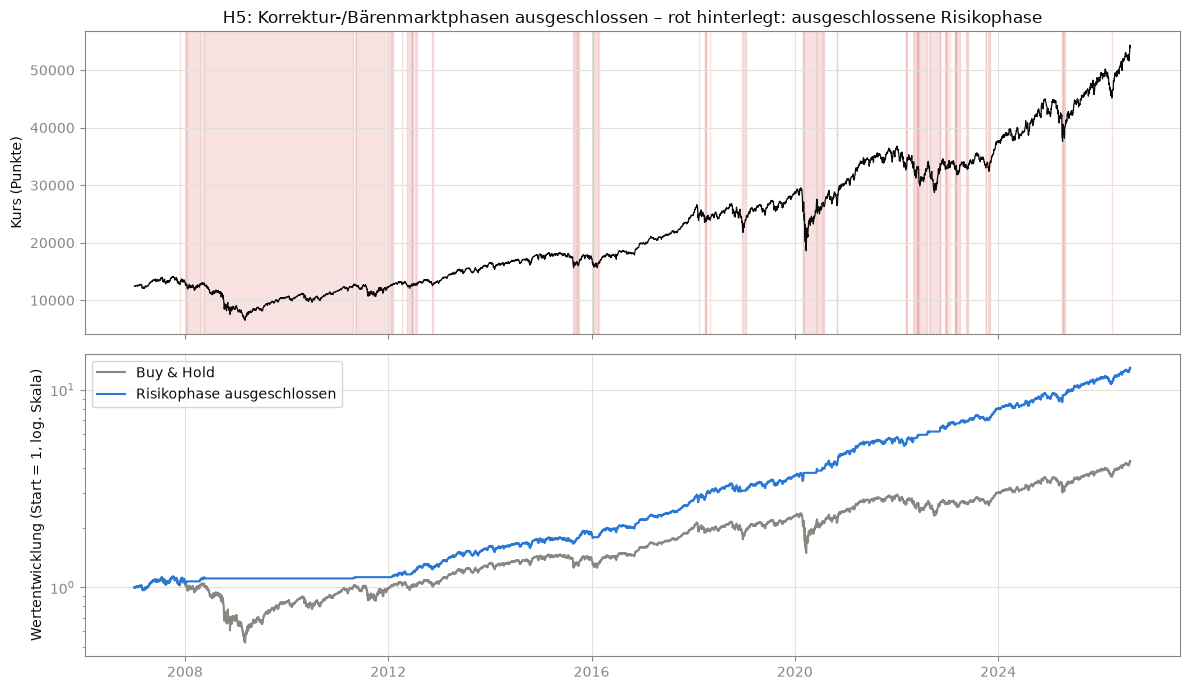

Anteil ausgeschlossener Handelstage: 28.5%
Gesamtrendite  - Buy & Hold: 333.2% | Ausschluss: 1186.4%
CAGR           - Buy & Hold: 7.8% | Ausschluss: 13.9%
Max Drawdown   - Buy & Hold: -53.8% | Ausschluss: -10.0%


In [55]:
_ = plotte_was_waere_wenn("H5_Drawdown", regime_definitionen["H5_Drawdown"], "H5: Korrektur-/Bärenmarktphasen ausgeschlossen")


**Ergebnis:** Der Ausschluss der 28,5 % Handelstage in Korrektur- oder
Bärenmarktphasen (mindestens 10 % unter dem bisherigen Hoch) senkt den Max
Drawdown von −53,8 % auf −10,0 % und erhöht die CAGR von 7,8 % auf
13,9 %.

**Praxisrelevanz für Börseninvestoren:** H5 benötigt keine SMA-Parameterwahl
und ist damit die am einfachsten kommunizierbare Risikokennzahl der
gesamten Analyse; das Ergebnis bestätigt, dass diese parameterfreie
Kennzahl in der Praxis eine ähnlich wirksame Risikosteuerung ermöglicht
wie die SMA-basierten Signale.

#### H6 – Überverkaufte Phasen (RSI < 30) ausgeschlossen


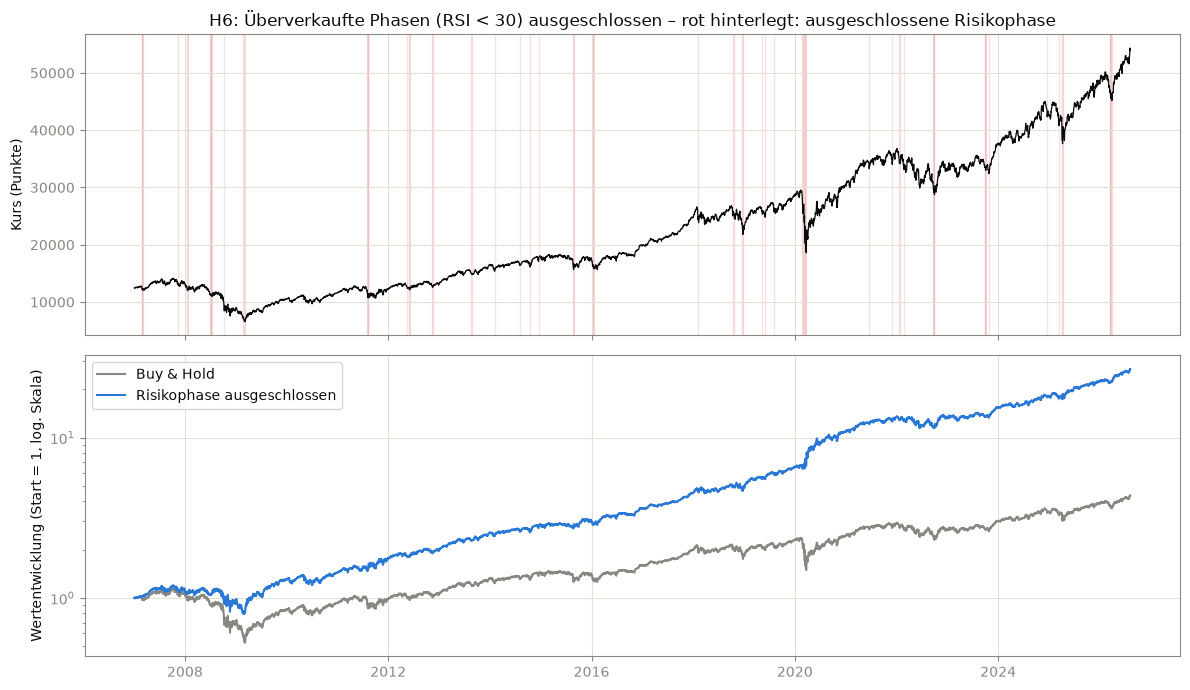

Anteil ausgeschlossener Handelstage: 2.1%
Gesamtrendite  - Buy & Hold: 333.2% | Ausschluss: 2563.0%
CAGR           - Buy & Hold: 7.8% | Ausschluss: 18.2%
Max Drawdown   - Buy & Hold: -53.8% | Ausschluss: -33.6%


In [56]:
_ = plotte_was_waere_wenn("H6_RSI_ueberverkauft", regime_definitionen["H6_RSI_ueberverkauft"], "H6: Überverkaufte Phasen (RSI < 30) ausgeschlossen")


**Ergebnis:** Obwohl RSI < 30 nur an 2,1 % der Handelstage auftritt, senkt
der Ausschluss dieser Tage den Max Drawdown bereits deutlich von −53,8 %
auf −33,6 % und erhöht die CAGR von 7,8 % auf 18,2 %.

**Praxisrelevanz für Börseninvestoren:** Dieses Ergebnis unterstreicht den
in Abschnitt 4.6 dokumentierten, kontraintuitiven Befund: Extreme
Überverkauft-Phasen konzentrieren sich zeitlich eng auf besonders
volatile Marktphasen. Wegen der geringen Anzahl betroffener Tage ist
RSI < 30 kein praktikables alleiniges Steuerungssignal, kann aber – wie in
Abschnitt 6.5 beschrieben – als punktueller Verschärfungshinweis innerhalb
einer Gelb-Phase dienen.

#### Kombinierte Ampel – Rot-Phasen ausgeschlossen


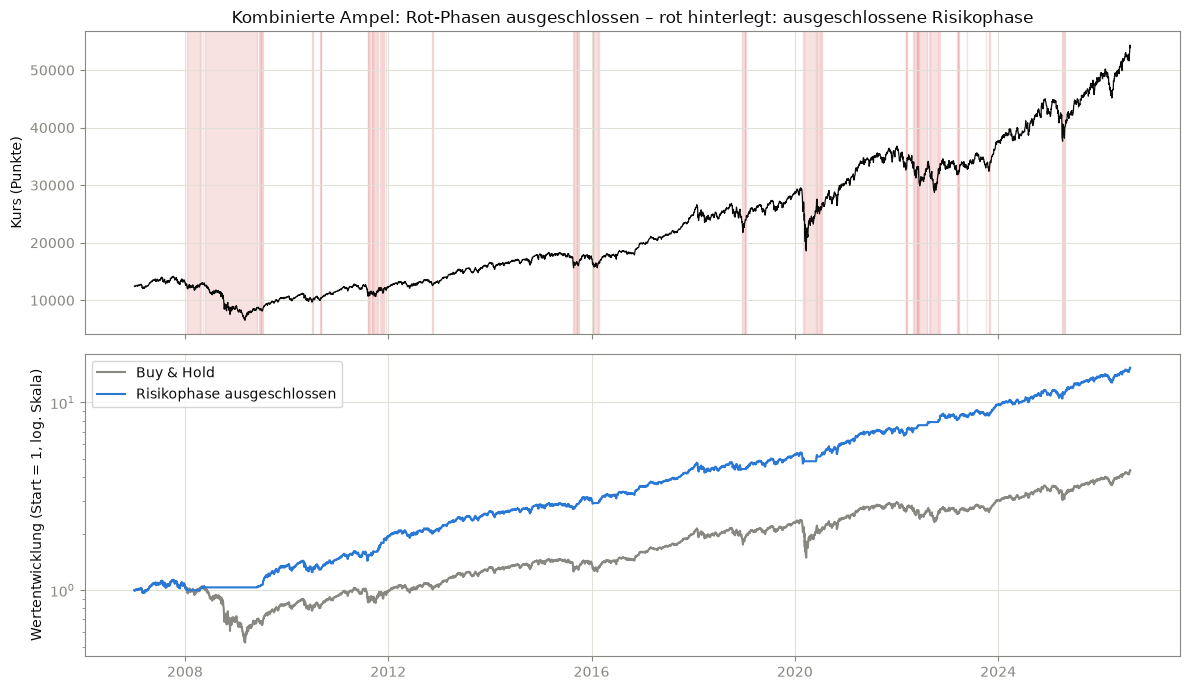

Anteil ausgeschlossener Handelstage: 14.2%
Gesamtrendite  - Buy & Hold: 333.2% | Ausschluss: 1426.7%
CAGR           - Buy & Hold: 7.8% | Ausschluss: 14.9%
Max Drawdown   - Buy & Hold: -53.8% | Ausschluss: -13.1%


In [57]:
_ = plotte_was_waere_wenn("Ampel_Rot", regime_definitionen["Ampel_Rot"], "Kombinierte Ampel: Rot-Phasen ausgeschlossen")


**Ergebnis:** Der Ausschluss der 14,2 % Rot-Handelstage senkt den Max
Drawdown von −53,8 % auf −13,1 % und erhöht die CAGR von 7,8 % auf 14,9 %.

**Praxisrelevanz für Börseninvestoren:** Die kombinierte Ampel schließt
mit 14,2 % deutlich weniger Handelstage aus als die Einzelbausteine H1, H2
und H5 (jeweils rund 26 bis 29 % bei den SMA200-/Drawdown-Parametrisierungen),
erzielt aber eine CAGR-Verbesserung im oberen Bereich dieser robusten
Einzelbausteine (vergleichbar mit H5) bei einem Max Drawdown auf Höhe von
H2/SMA200. Die Kombination reduziert damit die Zahl der als riskant
markierten Tage, ohne die Risikoreduktion der Einzelsignale wesentlich zu
verwässern – ein Beleg dafür, dass die in Abschnitt 6.3 definierte
Übereinstimmungsregel einen sinnvollen Kompromiss zwischen Selektivität
und Schutzwirkung darstellt.

### 7.5 Zusammenfassende Einordnung

Über alle betrachteten Hypothesen hinweg bestätigt die
Was-wäre-wenn-Analyse den in den Abschnitten 4.7 und 6.4 dokumentierten
Kernbefund aus einer weiteren, praxisnahen Perspektive: Regelbasierte
Ausschlussstrategien auf Basis von H1, H2 und H5 sowie der kombinierten
Ampel hätten den historischen Max Drawdown des Dow Jones auf rund ein
Fünftel bis ein Viertel des Buy-&-Hold-Werts reduziert, bei gleichzeitig
deutlich höherer annualisierter Rendite. H6 (RSI < 30) reduziert den Max
Drawdown ebenfalls erheblich, jedoch mit rund −33,6 % auf einen anteilig
höheren Wert (gut drei Fünftel von Buy & Hold) als die übrigen genannten
Bausteine – ein Nebeneffekt der sehr geringen Ausschlussquote von nur
2,1 % der Handelstage. Die beiden Cross-Over-Paare (H3) senken den Max
Drawdown zwar ebenfalls, jedoch deutlich schwächer (−19,3 % bis −25,6 %)
und – im Einklang mit ihrer bereits in Abschnitt 4.3 dokumentierten
schwachen statistischen Absicherung – ohne klaren Renditevorteil gegenüber
Buy & Hold. Die kombinierte Ampel liefert dabei mit einem vergleichsweise
geringen Anteil ausgeschlossener Handelstage (14,2 %) ein ausgewogenes
Ergebnis (Max Drawdown −13,1 %, CAGR 14,9 %) und bestätigt damit die in
Abschnitt 6 hergeleitete Kategorienregel auch aus Rendite-/Risikosicht.
Sämtliche Werte basieren auf einer vereinfachten Simulation ohne
Transaktionskosten und Cash-Verzinsung (siehe methodische Abgrenzung zu
Beginn dieses Abschnitts) und sind entsprechend als oberes Potenzial,
nicht als realistisch erzielbare Rendite zu verstehen.

## 8. Export der Ergebnisse

Sämtliche Ergebnistabellen werden als Einzel-CSV-Dateien sowie als
gemeinsame Excel-Arbeitsmappe (ein Tabellenblatt je Hypothese sowie die
Robustheitsübersicht) im Ordner `Hypothesenanalysen_Vertieft/` gespeichert.


In [58]:
INDEX_DATEINAME = INDEX_NAME.replace(" ", "_").replace("&", "and")

xlsx_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_hypothesenanalysen_vertieft.xlsx"
with pd.ExcelWriter(xlsx_pfad, engine="openpyxl") as writer:
    for name, tabelle in alle_ergebnisse.items():
        tabelle.to_excel(writer, sheet_name=name[:31], index=False)
    tabelle_robustheit.to_excel(writer, sheet_name="Robustheit_Uebersicht", index=False)
    # Ampel-Kategoriendefinition (Abschnitt 6) und Was-wäre-wenn-Kennzahlen
    # (Abschnitt 7) ergänzen die Hypothesentabellen um die abgeleitete
    # Anwendungssicht des Notebooks.
    tabelle_ampel.to_excel(writer, sheet_name="Ampel_Validierung", index=False)
    tabelle_was_waere_wenn.to_excel(writer, sheet_name="Was_waere_wenn", index=False)

csv_dateien = []
for name, tabelle in alle_ergebnisse.items():
    csv_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_{name}.csv"
    tabelle.to_csv(csv_pfad, index=False)
    csv_dateien.append(csv_pfad.name)

robustheit_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Robustheit_Uebersicht.csv"
tabelle_robustheit.to_csv(robustheit_csv, index=False)
csv_dateien.append(robustheit_csv.name)

ampel_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Ampel_Validierung.csv"
tabelle_ampel.to_csv(ampel_csv, index=False)
csv_dateien.append(ampel_csv.name)

was_waere_wenn_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Was_waere_wenn.csv"
tabelle_was_waere_wenn.to_csv(was_waere_wenn_csv, index=False)
csv_dateien.append(was_waere_wenn_csv.name)

print(f"Excel-Arbeitsmappe gespeichert: {xlsx_pfad}")
print("Einzel-CSV-Dateien gespeichert:")
for f in csv_dateien:
    print(" -", f)


Excel-Arbeitsmappe gespeichert: Hypothesenanalysen_Vertieft\Dow_Jones_hypothesenanalysen_vertieft.xlsx
Einzel-CSV-Dateien gespeichert:
 - Dow_Jones_H1_Kurs_vs_SMA.csv
 - Dow_Jones_H2_SMA_Richtung.csv
 - Dow_Jones_H3_CrossOver.csv
 - Dow_Jones_H4_Divergenz.csv
 - Dow_Jones_H5_Drawdown_vom_Hoch.csv
 - Dow_Jones_H6_Momentum_RSI.csv
 - Dow_Jones_Robustheit_Uebersicht.csv
 - Dow_Jones_Ampel_Validierung.csv
 - Dow_Jones_Was_waere_wenn.csv


## 9. Zusammenfassung

Diese Analyse hat sechs Hypothesen zur Aussagekraft SMA-basierter und
verwandter technischer Indikatoren für den Dow Jones im Zeitraum 2007 bis
2026 systematisch geprüft, für sämtliche untersuchten Parametrisierungen
grafisch ausgewertet und hinsichtlich ihrer Eignung für ein Ampelsystem
bewertet.

**Kernergebnis:** Die robustesten Bausteine sind die Trendposition und
-richtung des Kurses relativ zum SMA200 (H1, H2) sowie der Abstand vom
bisherigen Höchststand (H5). Bei allen drei ist das Risikosignal
durchgängig statistisch abgesichert; bei H1 und H5 zeigt sich zusätzlich
auch ein überwiegend bis durchgängig signifikantes Renditesignal, während
sich bei kurzfristigen Zeitfenstern (SMA20, SMA100) ein signifikant
gegenläufiges Renditeverhalten zeigt (Mean-Reversion). Cross-Over- (H3)
und Divergenzsignale (H4) leiden unter zu geringer Ereignishäufigkeit,
insbesondere auf Wochen- und Monatsbasis. Der RSI (H6) zeigt entgegen der
klassischen Lehrmeinung keinen Umkehreffekt, sondern in den kürzeren
Horizonten einen konsistenten Risiko-Rendite-Zusammenhang mit signifikant
höherer Rendite und höherem Risiko nach überverkauften Phasen.

**Schlussfolgerung für das Ampelsystem:** Ein trendbasiertes Ampelsystem
für den Dow Jones sollte primär als Risikoindikator ausgelegt werden, mit
H1/H2 (SMA200) und H5 als Kernbausteinen. Die vorliegenden Ergebnistabellen
(Abschnitt 6) bilden die quantitative Grundlage für die Kalibrierung
entsprechender Schwellenwerte.

**Ampel-Systematik und Was-wäre-wenn-Analyse:** Abschnitt 6 leitet aus H1,
H2 und H5 eine dreistufige Ampel-Kategorisierung (Grün/Gelb/Rot) ab, deren
Risikotrennung über alle drei Farbpaare und Prognosehorizonte durchgängig
statistisch signifikant ist (Abschnitt 6.4). Die Was-wäre-wenn-Analyse in
Abschnitt 7 zeigt, dass ein Ausschluss der jeweils ungünstigeren
Regimephase den historischen Max Drawdown des Dow Jones in nahezu allen
betrachteten Parametrisierungen deutlich reduziert hätte – bei der
kombinierten Ampel von −53,8 % auf −13,1 %, bei gleichzeitig höherer
annualisierter Rendite (14,9 % statt 7,8 %). Diese Ergebnisse beruhen auf
einer vereinfachten Simulation ohne Transaktionskosten und sind als Beleg
für das grundsätzliche Potenzial, nicht als realistisch handelbare
Strategie zu verstehen.